# Dolphins

In [1]:
import sys
import os
sys.path.append(os.path.abspath("..\\.."))
from Modules.latentspacemodel import *
from Modules.inference import *
from Modules.afteranalyses import *

## Network

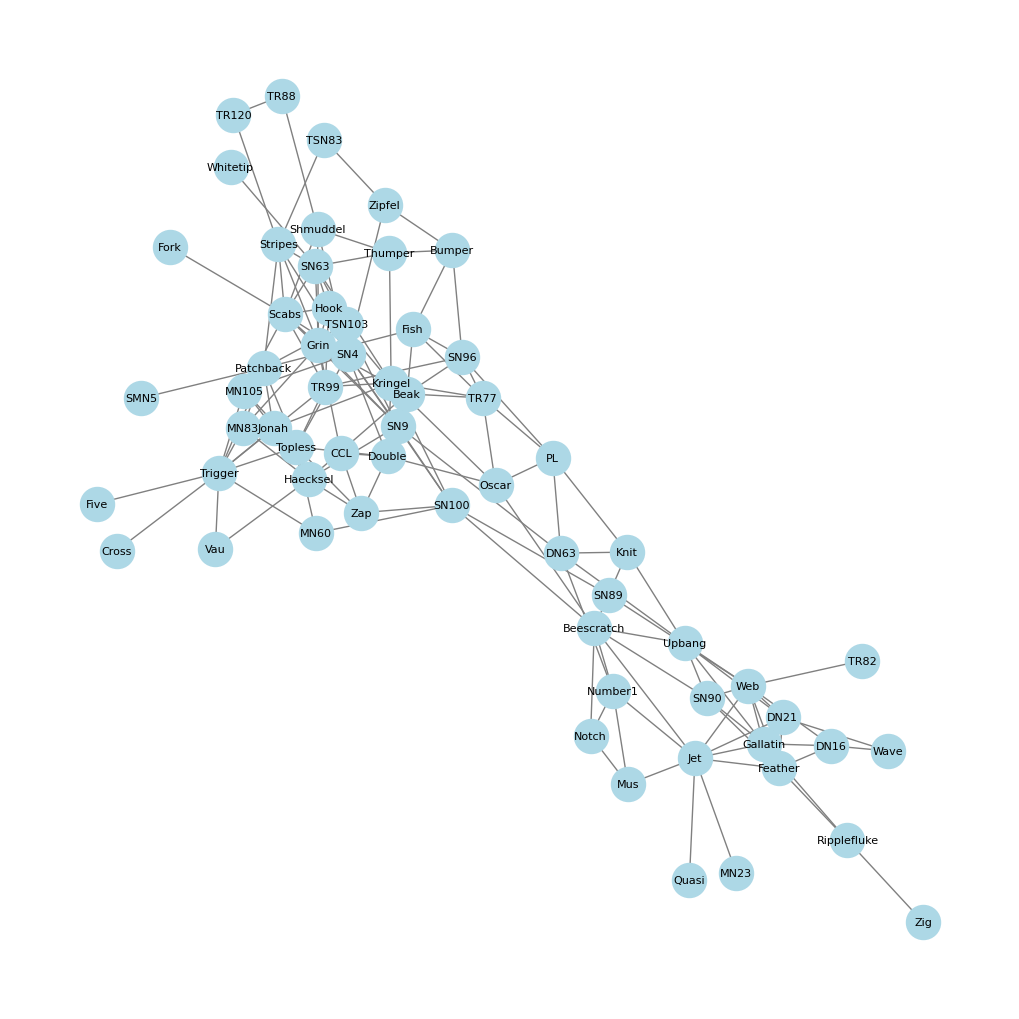

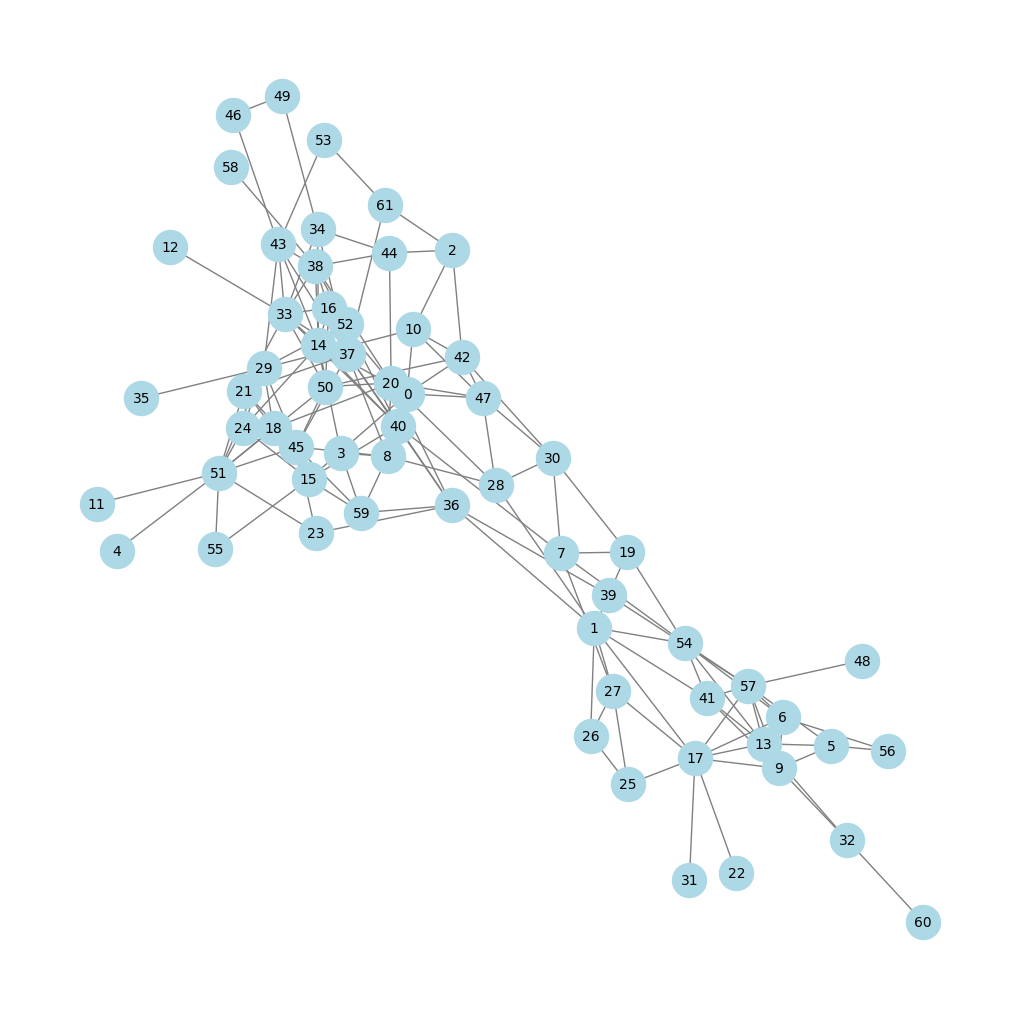

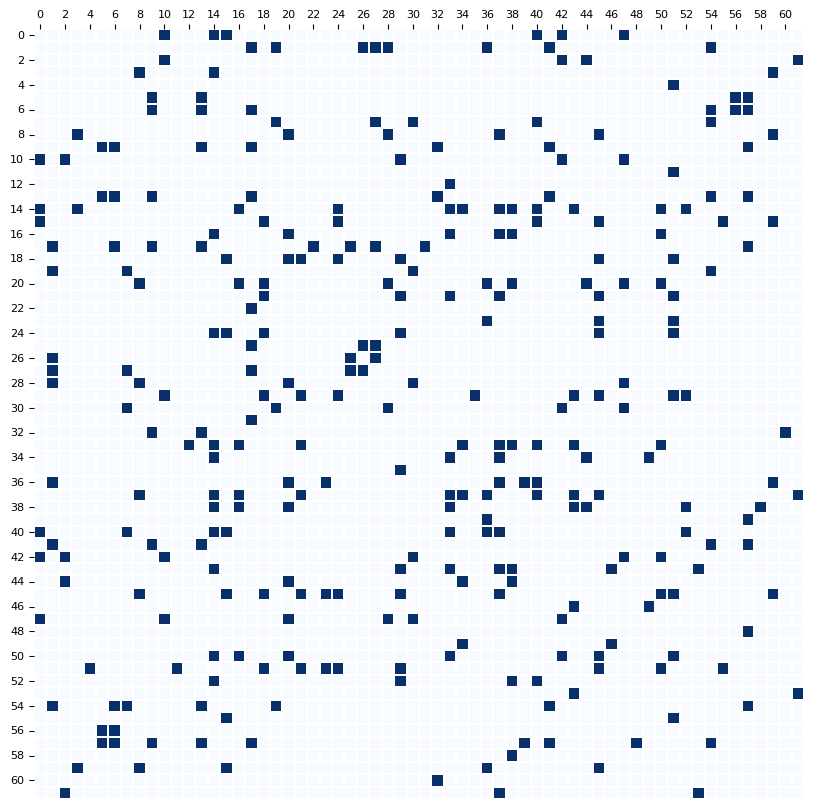

In [15]:
G = nx.read_gml("C://Users//carlo//OneDrive//Documents//Latentspacemodels_Networks//Complement//Examples//Dolphins//network_clean.gml")

pos = nx.spring_layout(G, seed=80)
plt.figure(figsize=(10,10))
nx.draw(G, pos=pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=600, font_size=8)
plt.show()

node_mapping = {node: i for i, node in enumerate(G.nodes())}
G = nx.relabel_nodes(G, node_mapping)
pos_relabel = {node_mapping[k]: v for k, v in pos.items()}
plt.figure(figsize=(10,10))
nx.draw(G, pos=pos_relabel, with_labels=True, node_color="lightblue", edge_color="gray", node_size=600, font_size=10)
plt.show()
inverse_mapping = {v: k for k, v in node_mapping.items()}

Y = nx.to_numpy_array(G, dtype=int)
Y = (Y > 0).astype(int)
n = Y.shape[0]
plt.figure(figsize=(10,10))

sns.heatmap(Y, annot=False, cmap="Blues", cbar=False, square=True, linewidths=0.3, linecolor="white")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().xaxis.tick_top()
plt.gca().tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=8)
plt.show()

In [16]:
seed_MAP = 42
diam = 20.0
n = Y.shape[0]
lr_MAP = 1e-2
n_starts_MAP = 1
n_iter_MAP = 20000
n_sim_iv = 2000
n_iter_cv = 2000
n_folds_cv = 5

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

#### With weights

Multi_start (1)


MAP:  44%|████▎     | 8701/20000 [00:38<00:50, 224.40it/s, logpost=-34.6350, loglik=-34.0781, logprior=-0.5568, patience=100]


[STOP] Early stopping at iter 8700 (no improvement in 101 steps)

Best log-posterior: -34.6350


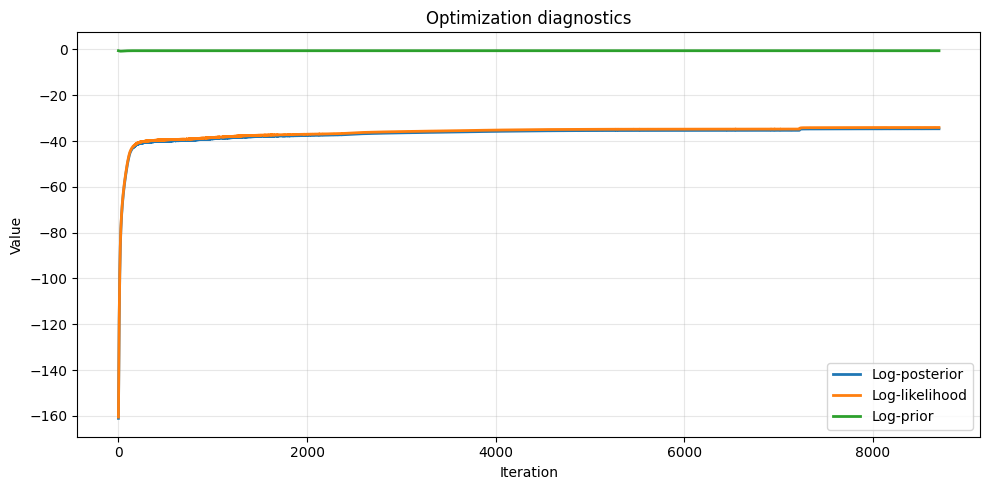

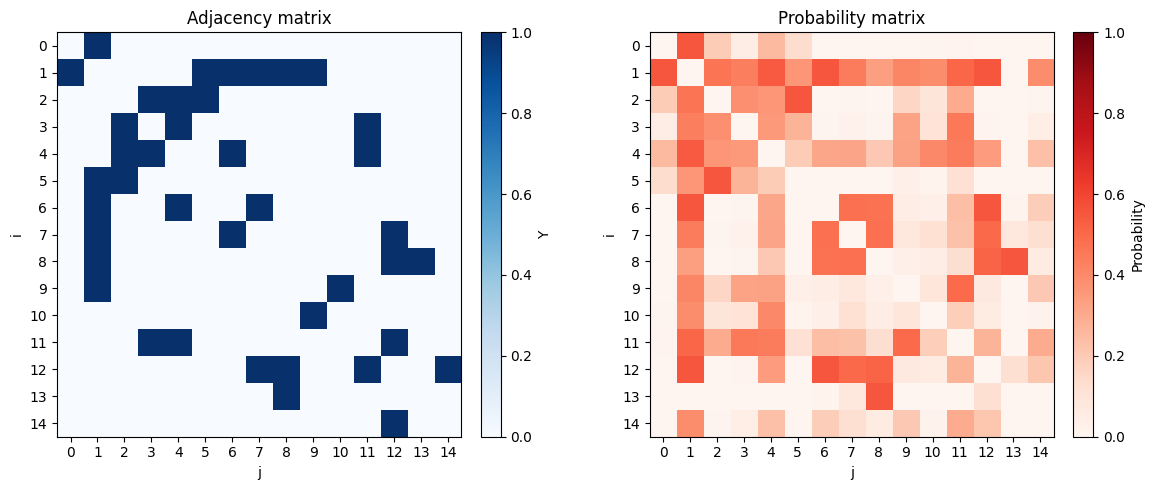

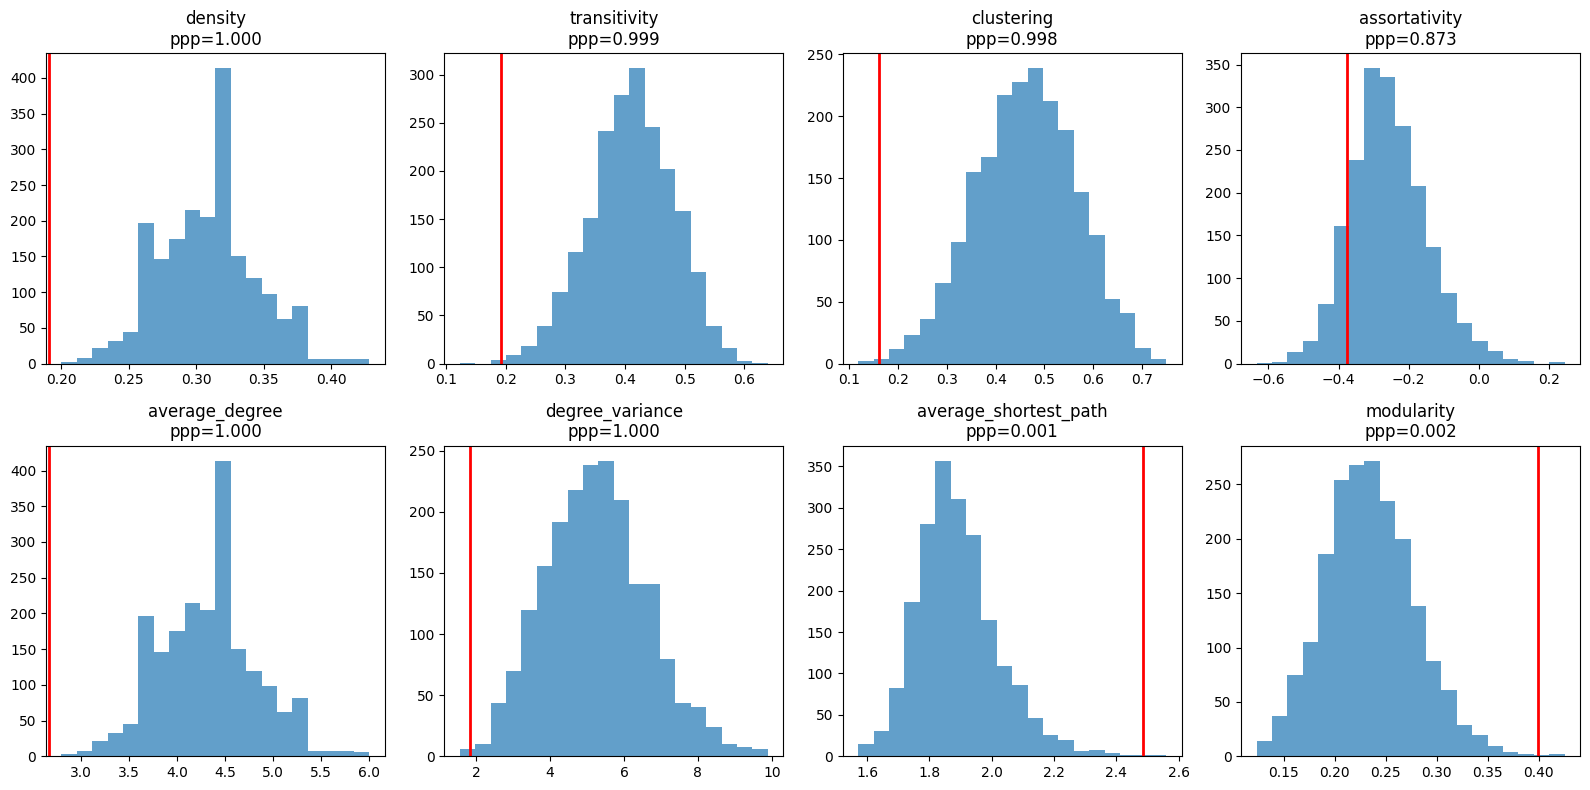

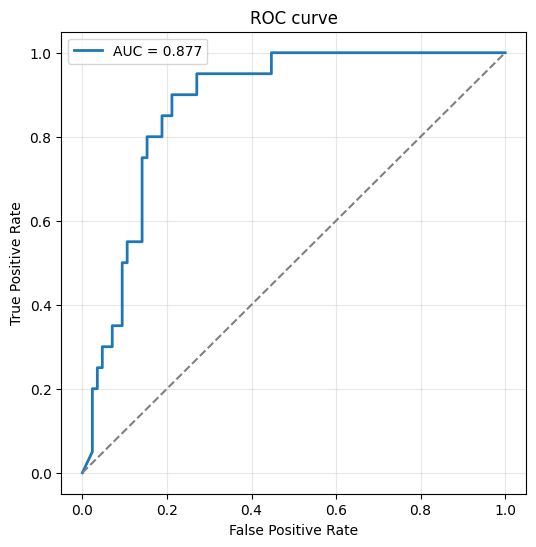

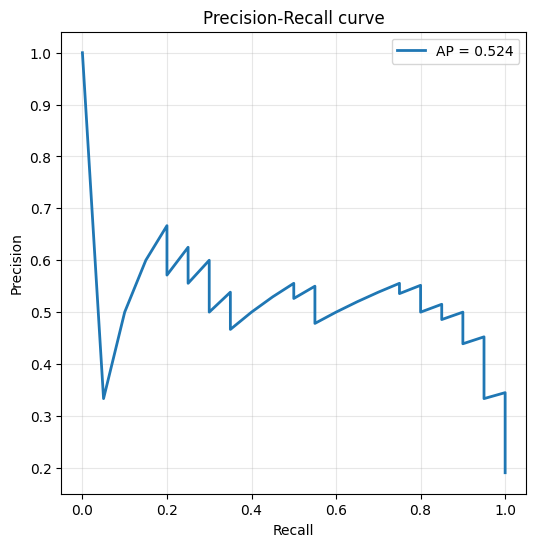

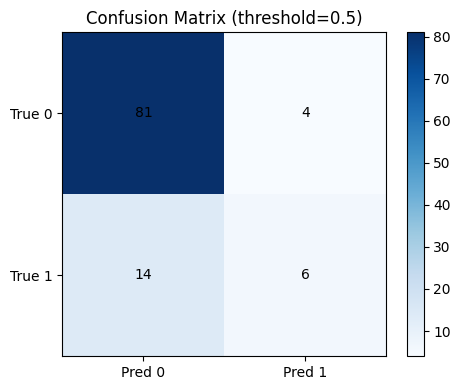

MAP: 100%|██████████| 2000/2000 [00:09<00:00, 214.95it/s, logpost=-23.6947, loglik=-23.1359, logprior=-0.5588, patience=0] 


{'mean_auc': 0.5009826854718495, 'std_auc': 0.16260279509981918, 'min_auc': np.float64(0.3235294117647059), 'max_auc': np.float64(0.75), 'n_folds': 5}


In [4]:
geometry = EuclideanGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R1_p.pkl")

#### Without weights

Multi_start (1)


MAP:   8%|▊         | 1590/20000 [00:07<01:25, 215.73it/s, logpost=-43.2666, loglik=-42.7173, logprior=-0.5493, patience=100]


[STOP] Early stopping at iter 1589 (no improvement in 101 steps)

Best log-posterior: -43.2666


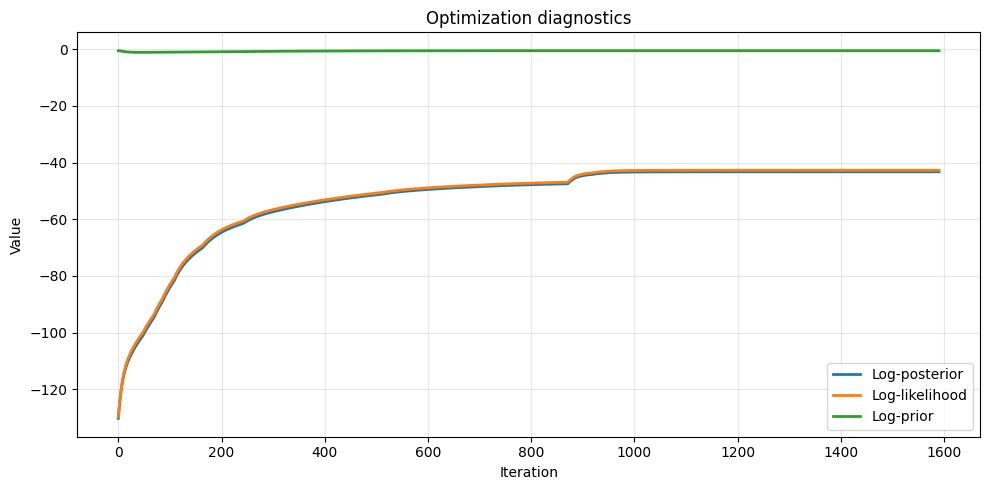

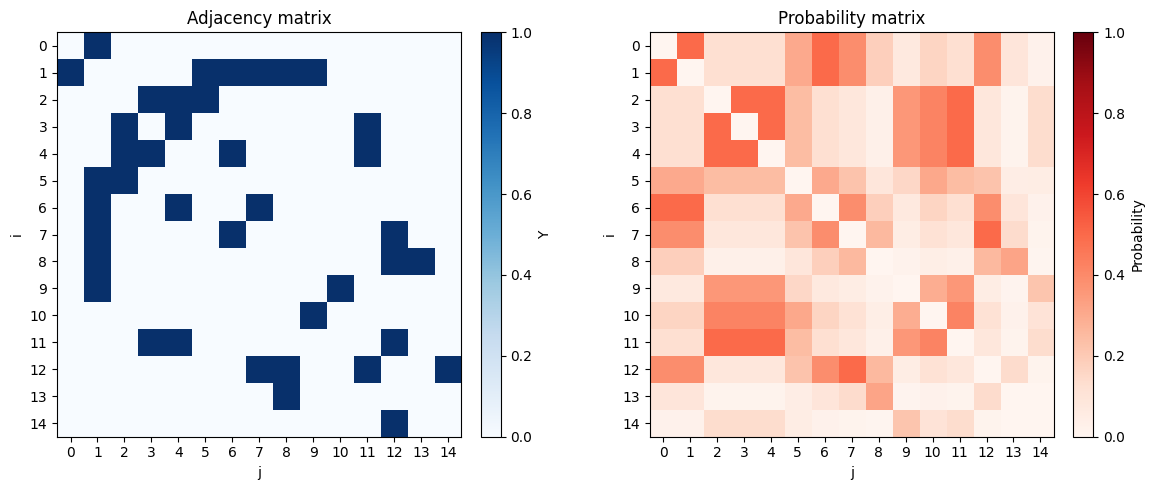

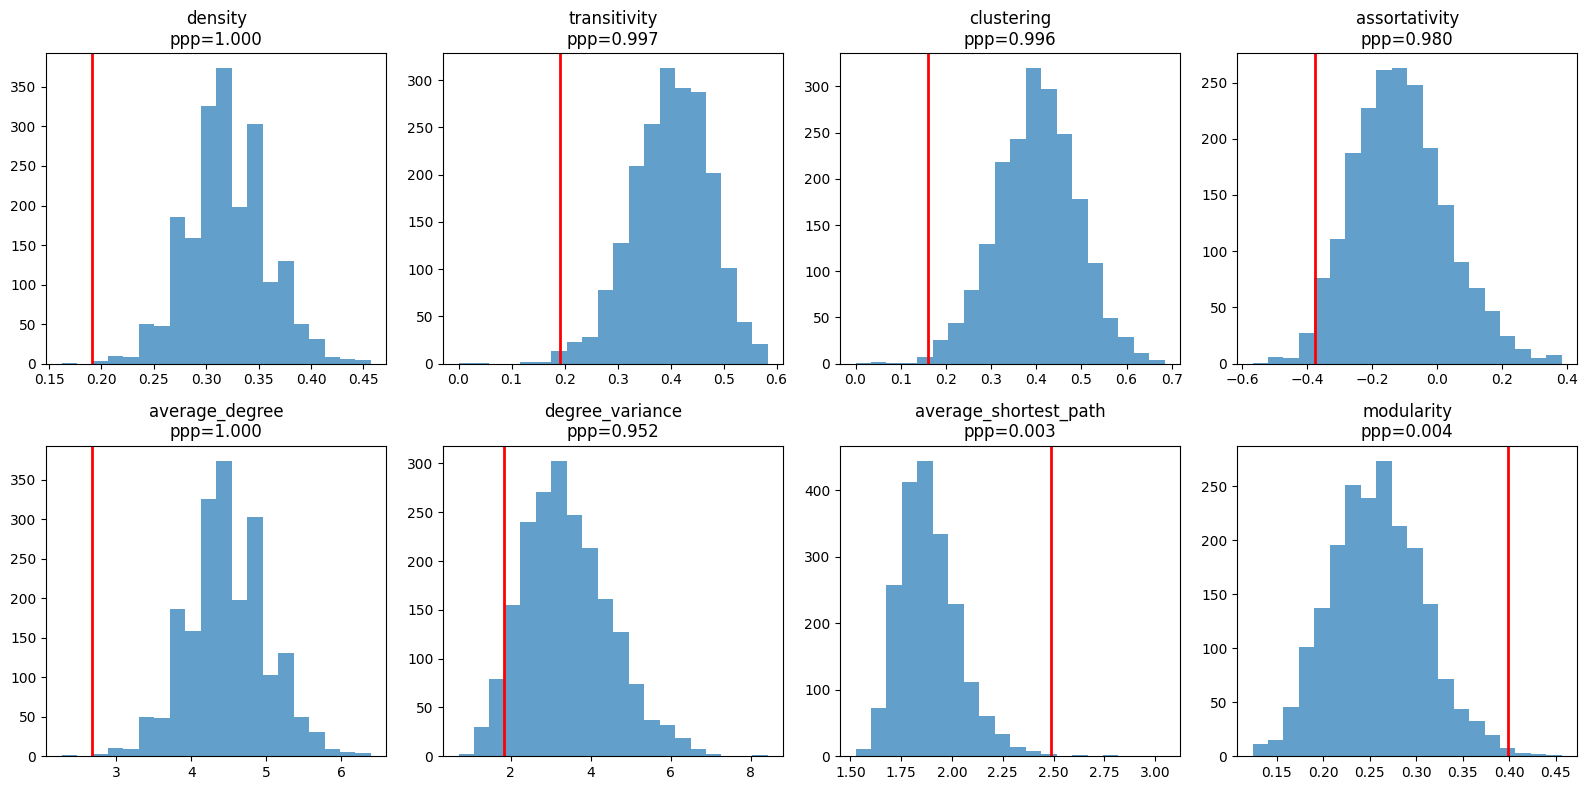

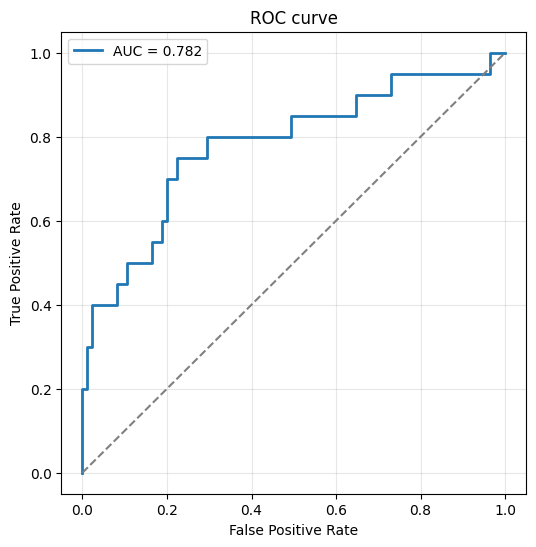

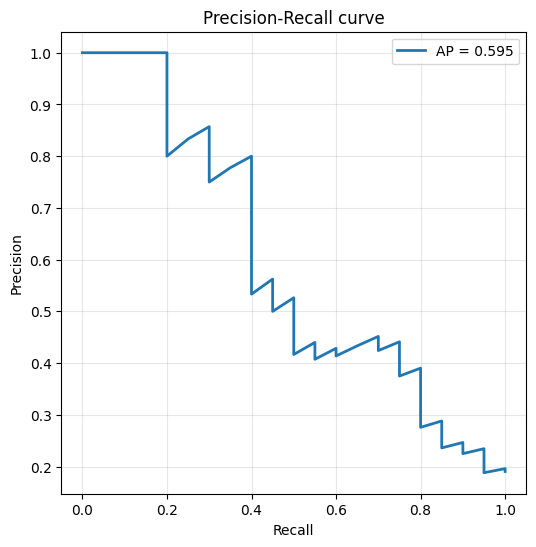

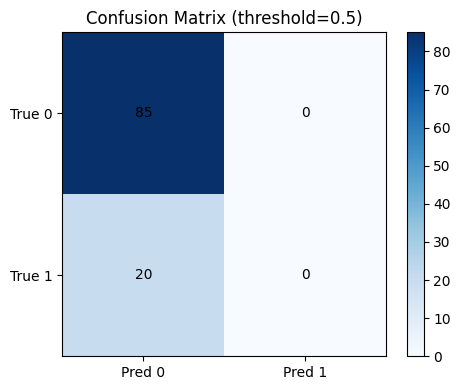

MAP: 100%|██████████| 2000/2000 [00:08<00:00, 233.52it/s, logpost=-27.9001, loglik=-27.3501, logprior=-0.5501, patience=5] 


{'mean_auc': 0.702049936933838, 'std_auc': 0.15225636572391518, 'min_auc': np.float64(0.5111111111111111), 'max_auc': np.float64(0.9473684210526316), 'n_folds': 5}


In [5]:
geometry = EuclideanGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R1_c.pkl")

### Model $\mathbb{R}^2$

#### With weights

Multi_start (1)


MAP: 100%|██████████| 20000/20000 [01:29<00:00, 222.53it/s, logpost=-15.7242, loglik=-13.3015, logprior=-2.4228, patience=0]



Best log-posterior: -15.7242


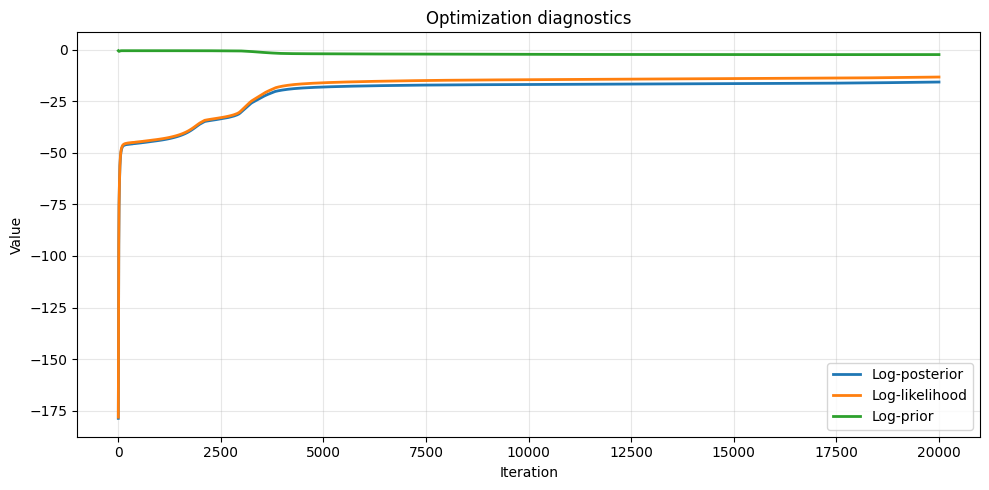

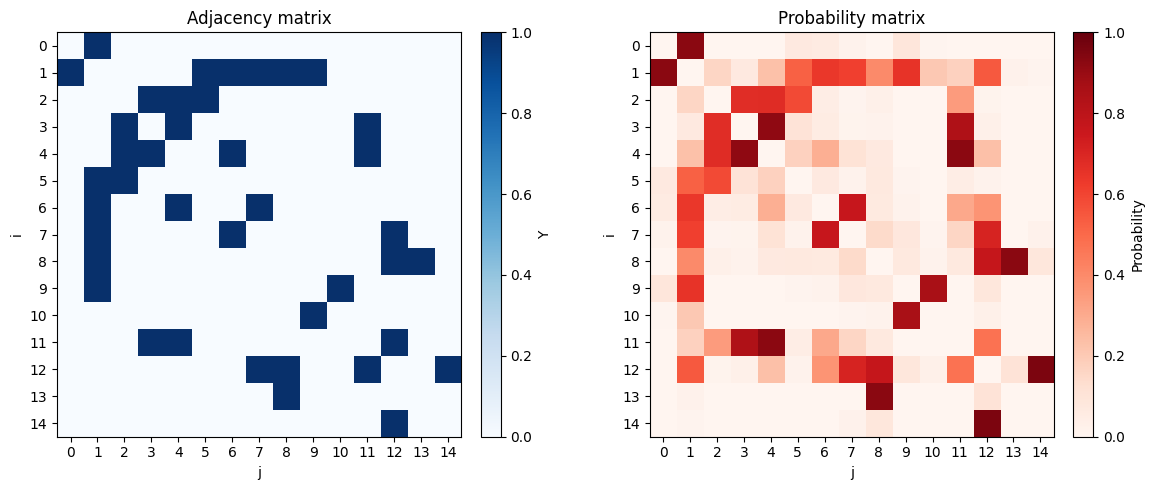

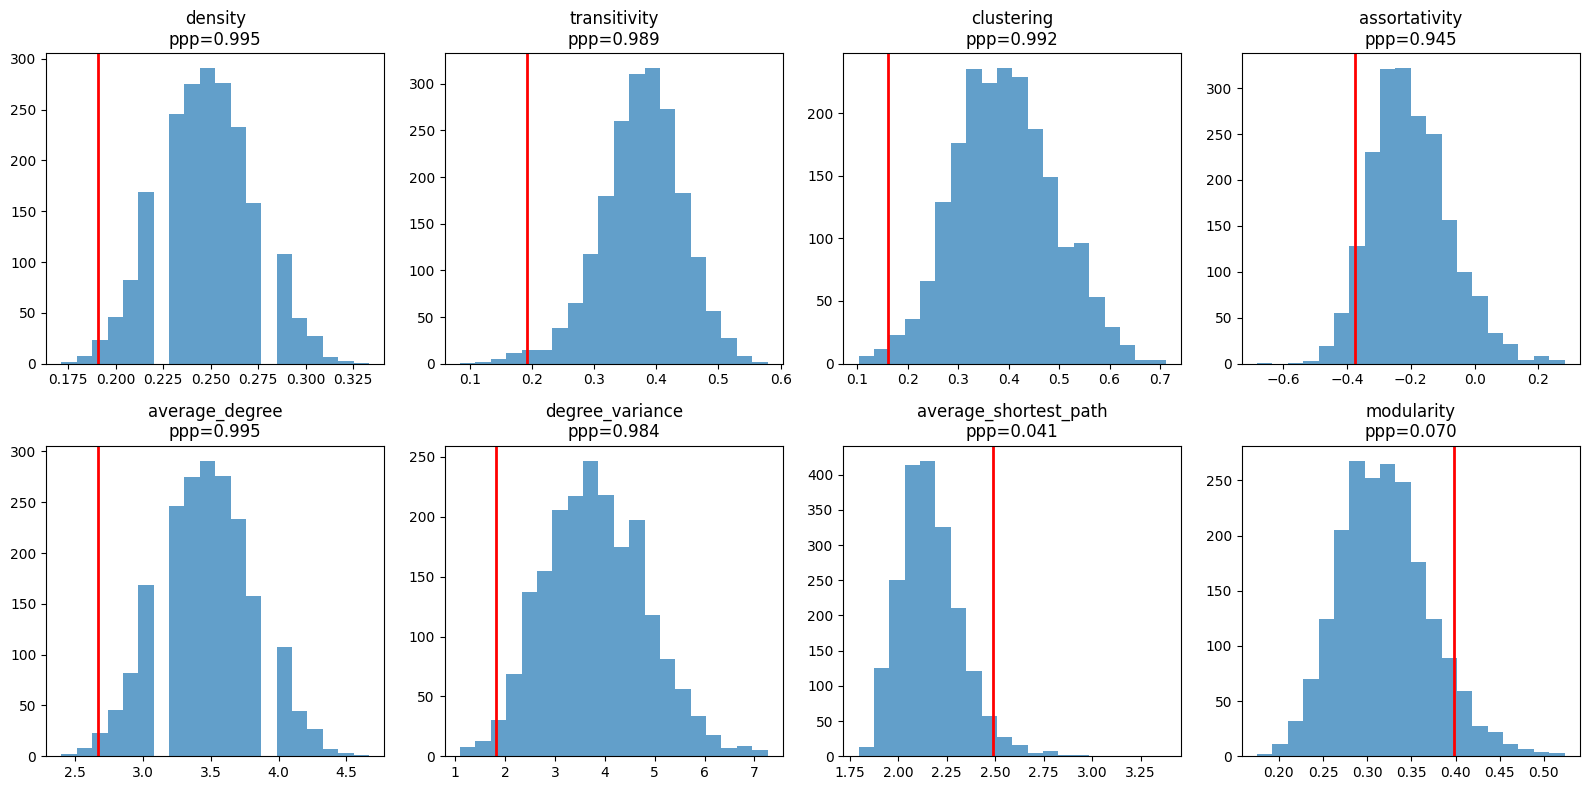

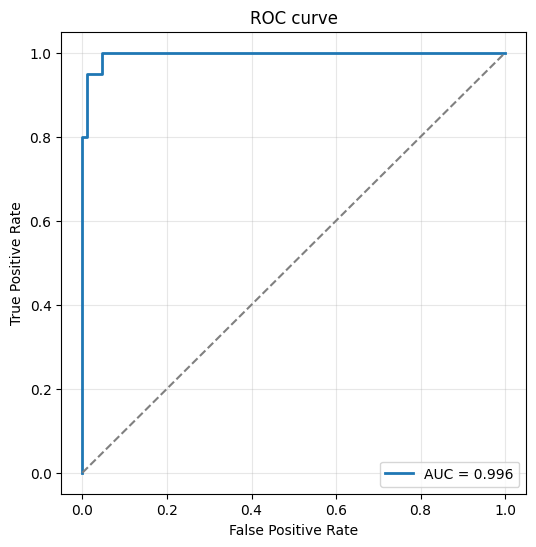

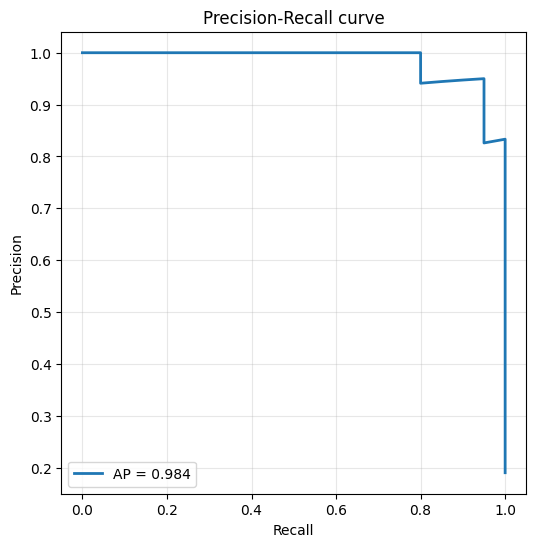

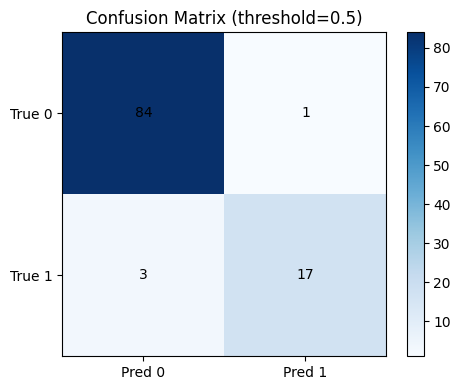

MAP: 100%|██████████| 2000/2000 [00:08<00:00, 225.16it/s, logpost=-6.6843, loglik=-5.0931, logprior=-1.5912, patience=1]


{'mean_auc': 0.7358264533883729, 'std_auc': 0.09953038835258857, 'min_auc': np.float64(0.6111111111111112), 'max_auc': np.float64(0.894736842105263), 'n_folds': 5}


In [6]:
geometry = EuclideanGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R2_p.pkl")

#### Without weigths

Multi_start (1)


MAP: 100%|██████████| 20000/20000 [01:25<00:00, 234.72it/s, logpost=-19.3836, loglik=-14.7668, logprior=-4.6168, patience=2] 



Best log-posterior: -19.3836


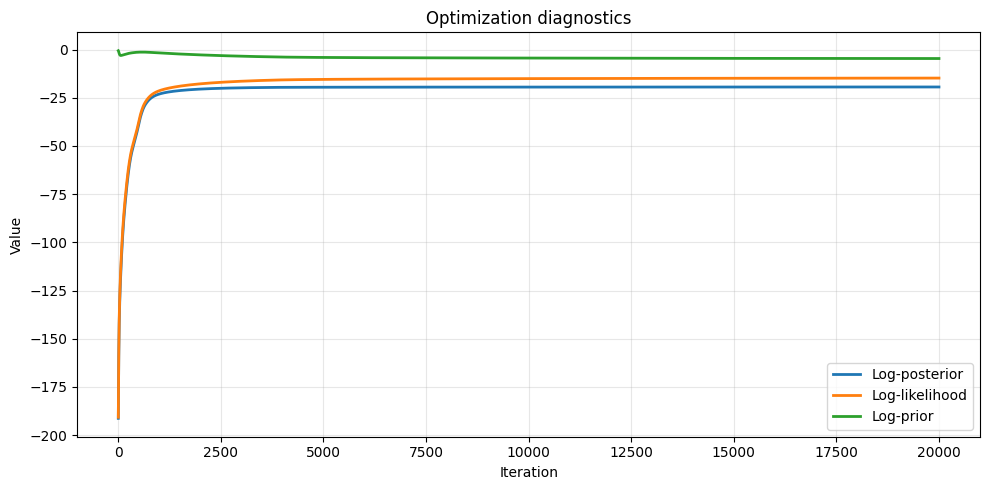

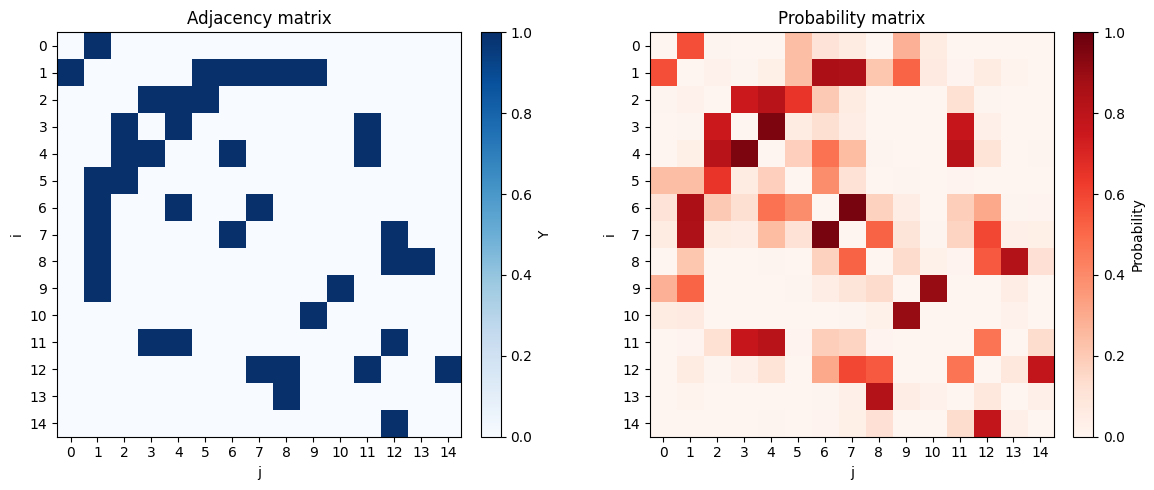

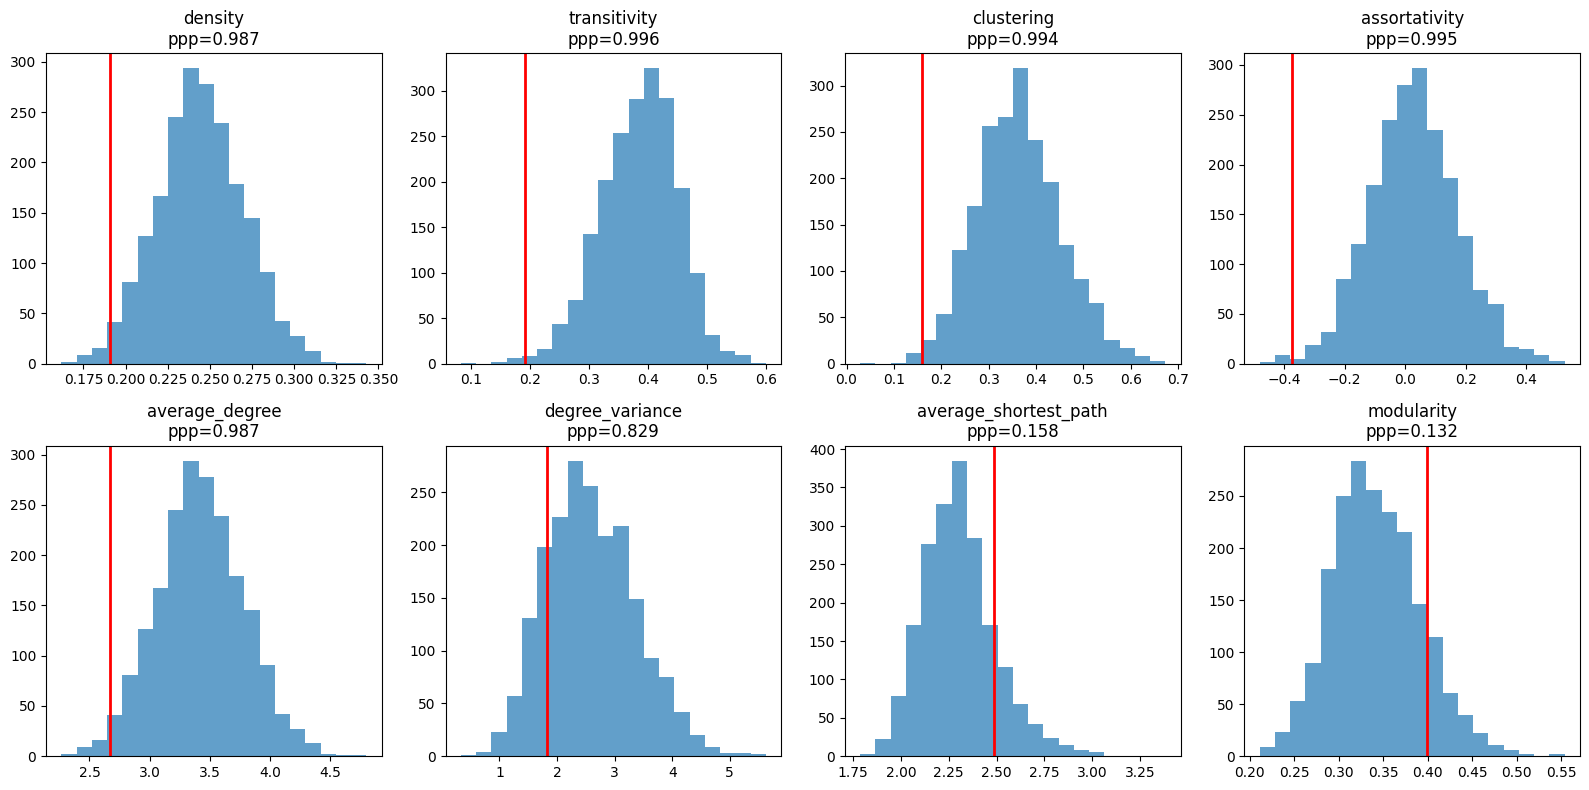

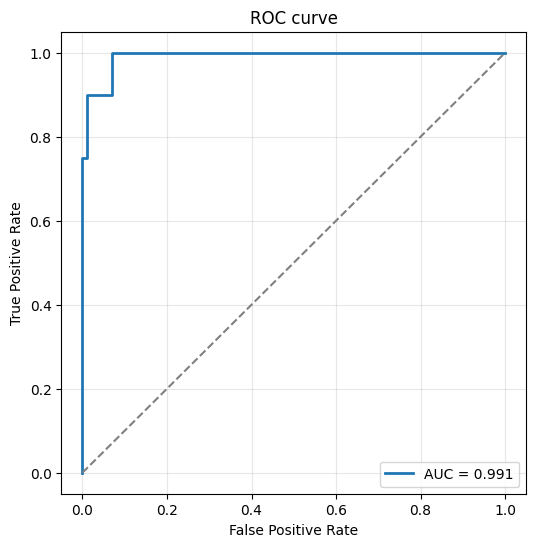

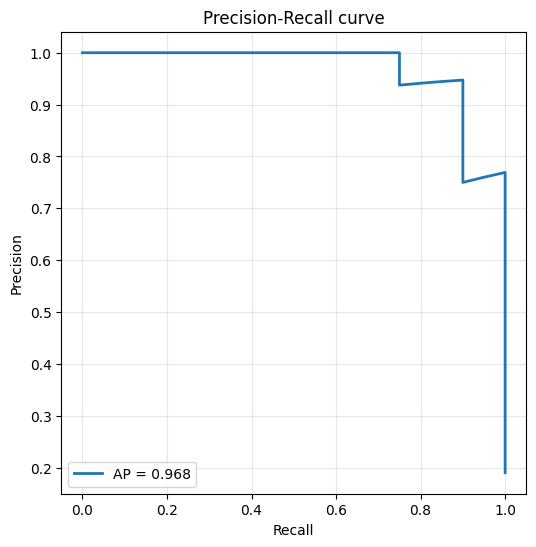

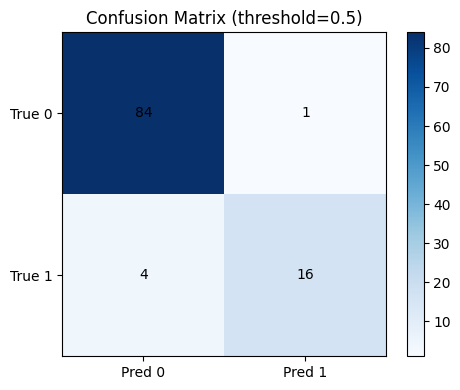

MAP: 100%|██████████| 2000/2000 [00:09<00:00, 215.13it/s, logpost=-9.2364, loglik=-5.9737, logprior=-3.2626, patience=0]


{'mean_auc': 0.795243664717349, 'std_auc': 0.13142707862594663, 'min_auc': np.float64(0.6481481481481481), 'max_auc': np.float64(1.0), 'n_folds': 5}


In [7]:
geometry = EuclideanGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R2_c.pkl")

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

#### With weights

Multi_start (1)


MAP: 100%|██████████| 20000/20000 [01:25<00:00, 234.67it/s, logpost=-39.2298, loglik=-38.6686, logprior=-0.5612, patience=21]



Best log-posterior: -39.2298


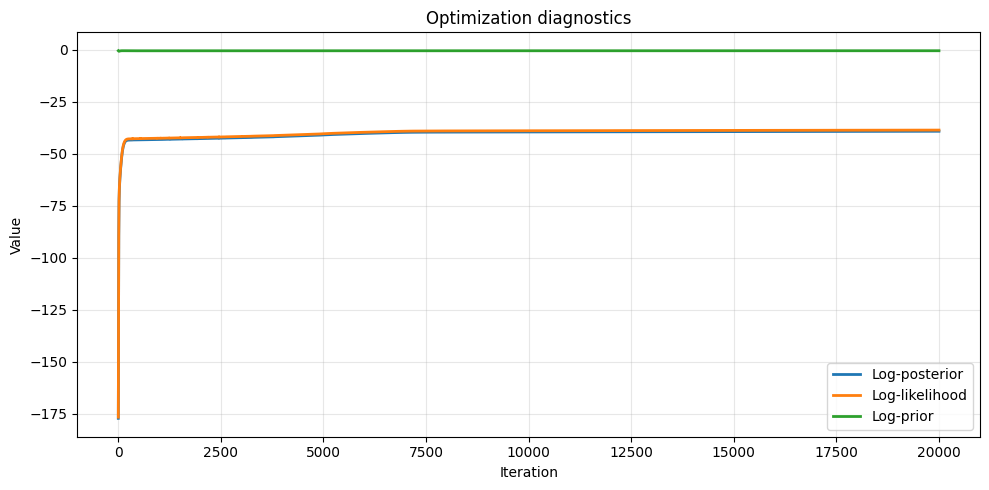

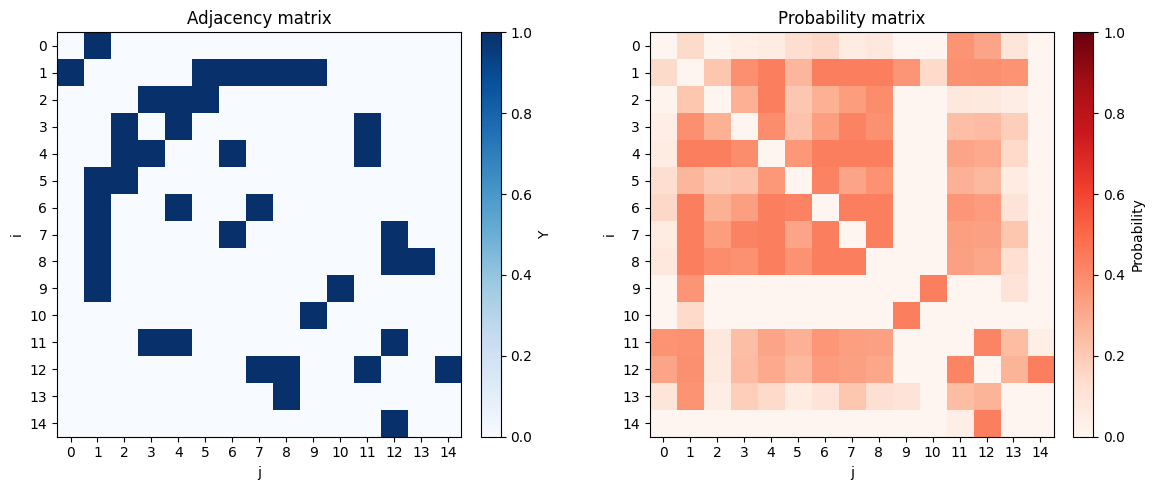

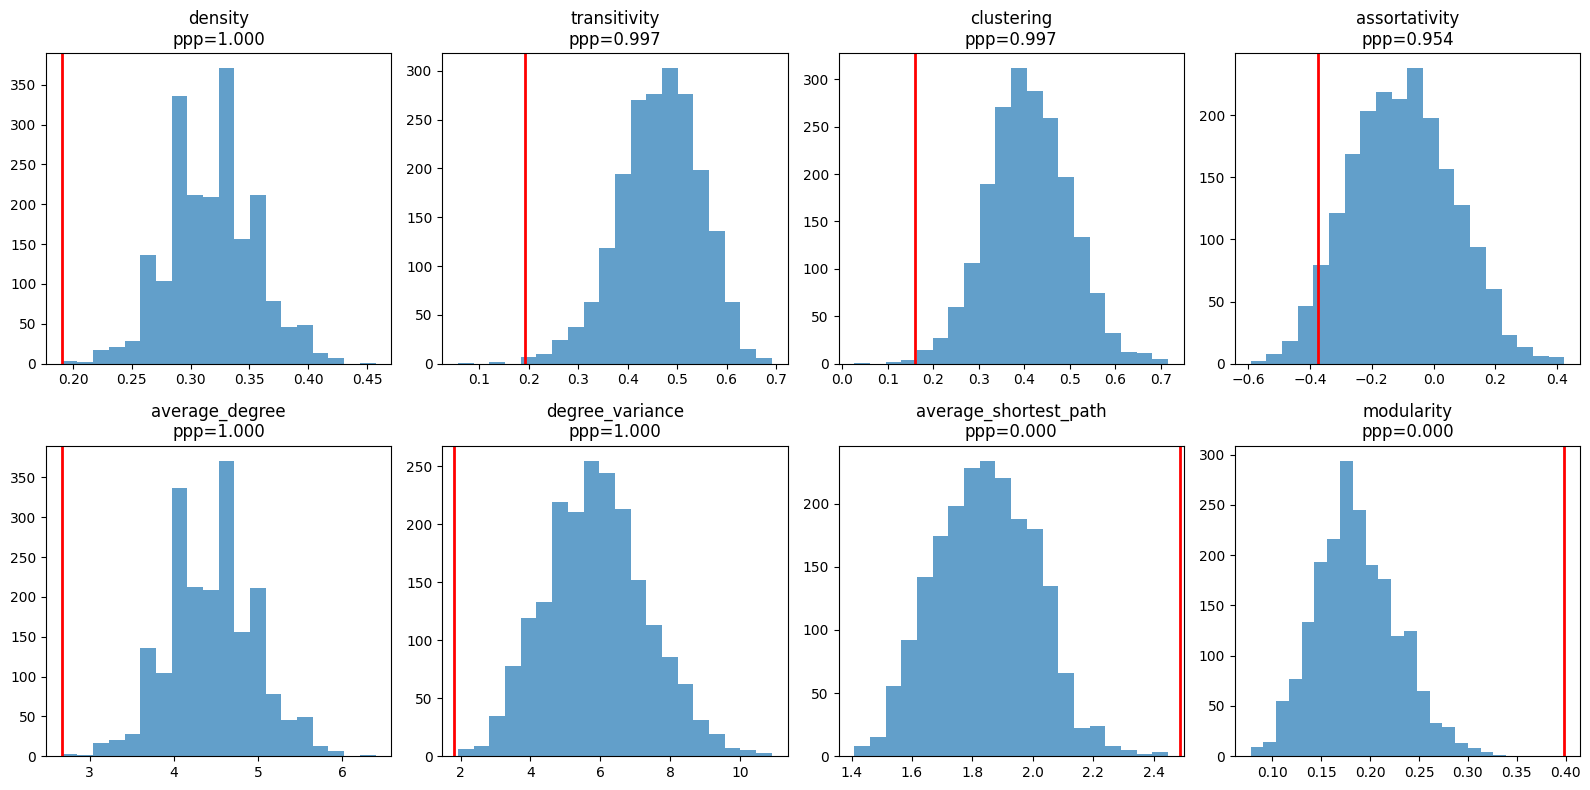

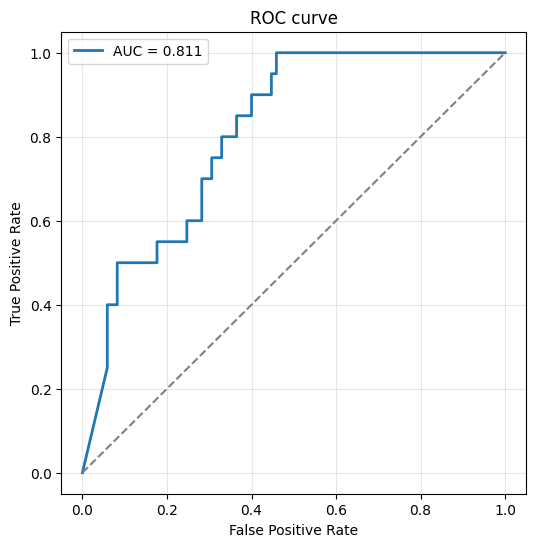

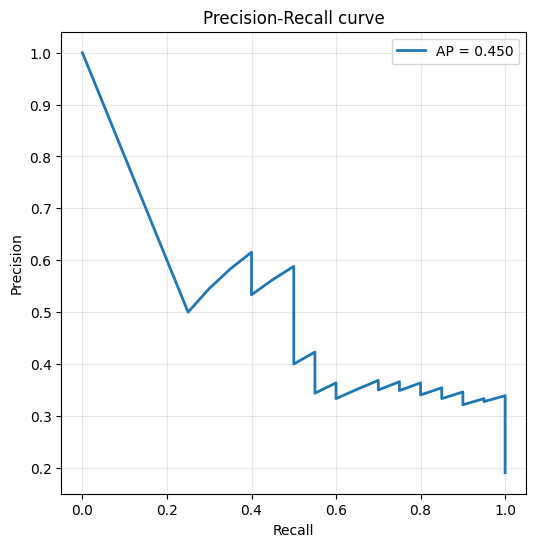

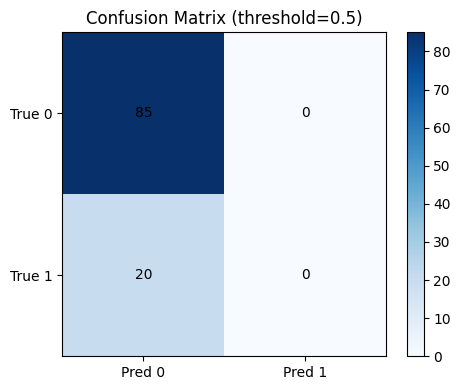

MAP: 100%|██████████| 2000/2000 [00:08<00:00, 223.17it/s, logpost=-22.2877, loglik=-21.7229, logprior=-0.5648, patience=0]


{'mean_auc': 0.4920992432060543, 'std_auc': 0.10832485792218284, 'min_auc': np.float64(0.368421052631579), 'max_auc': np.float64(0.6323529411764706), 'n_folds': 5}


In [8]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S1_p.pkl")

#### Without weights

Multi_start (1)


MAP: 100%|██████████| 20000/20000 [01:24<00:00, 237.52it/s, logpost=-106.7987, loglik=-105.4821, logprior=-1.3166, patience=0]



Best log-posterior: -106.7987


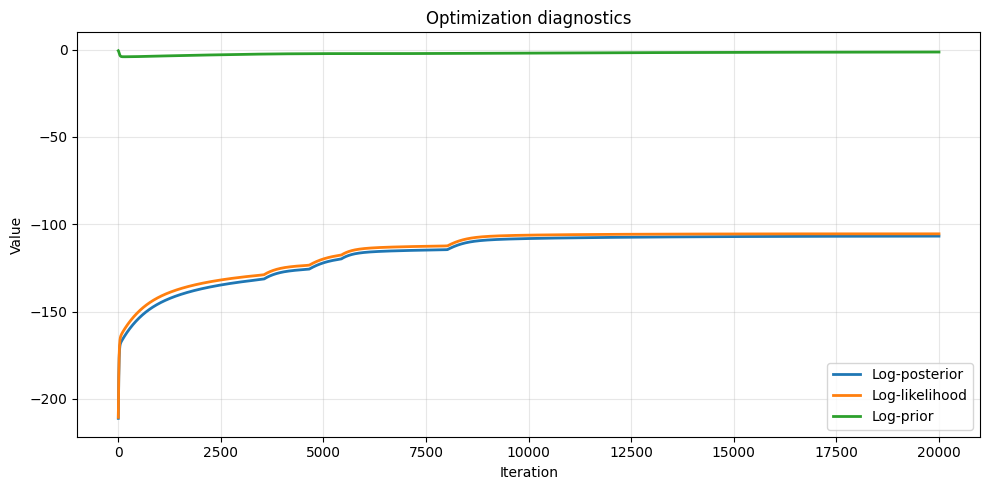

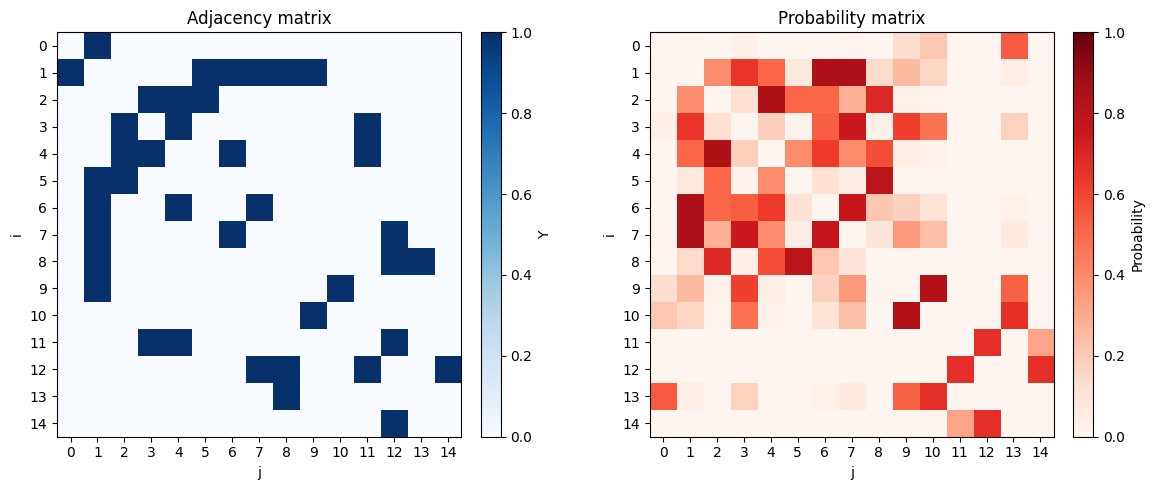

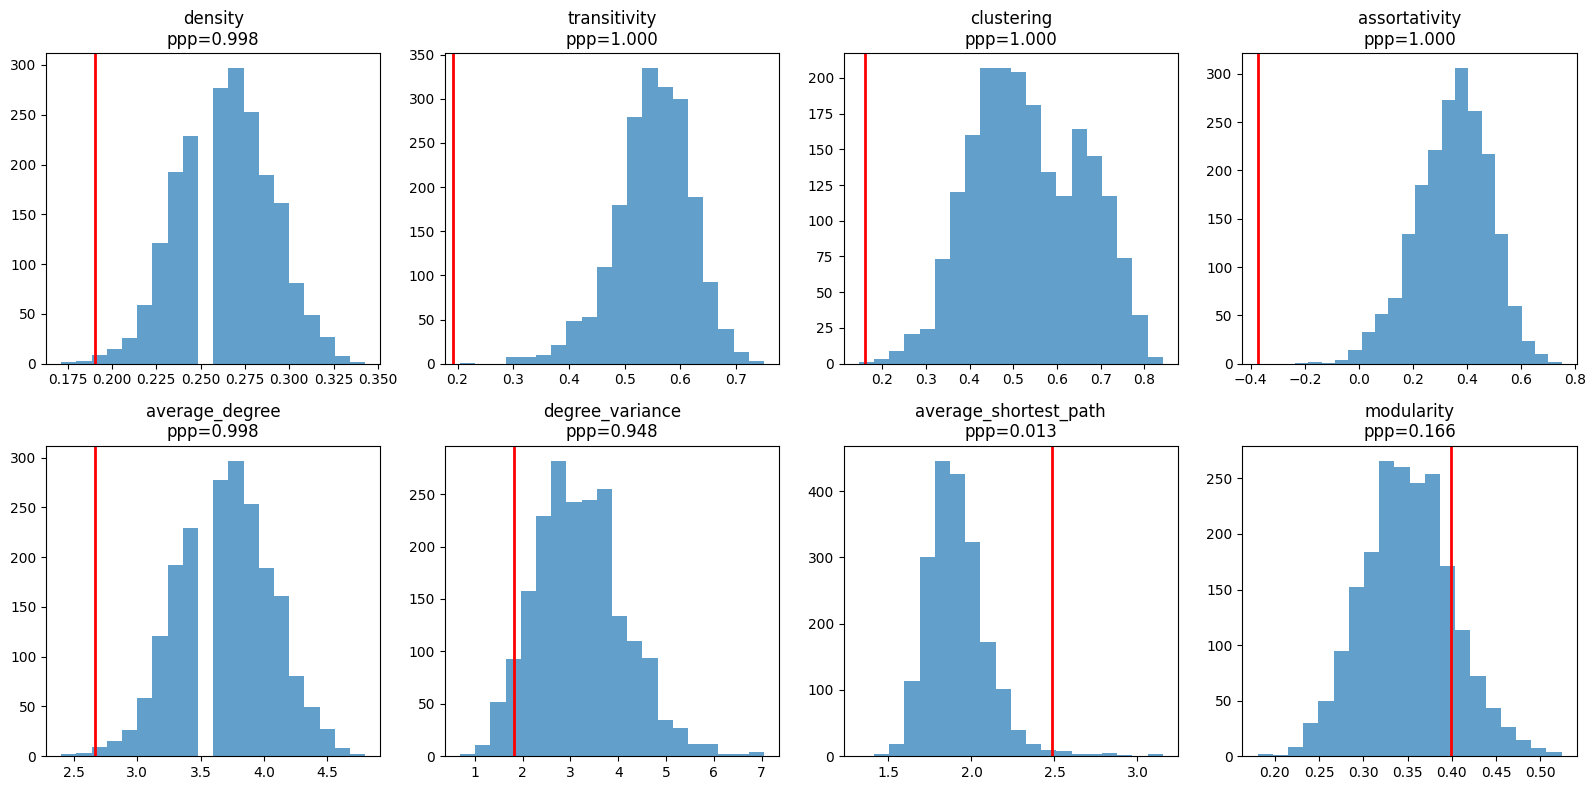

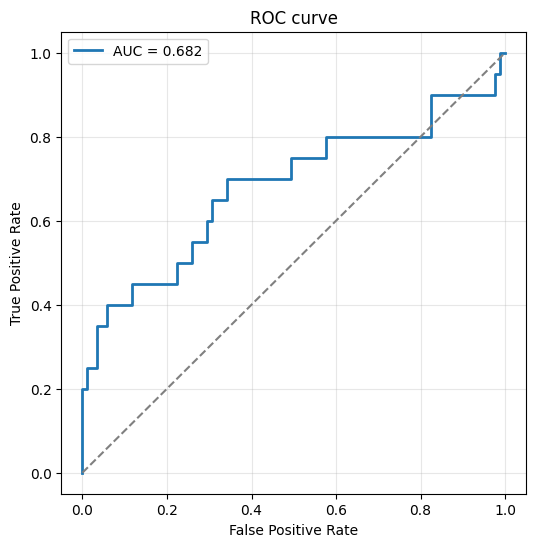

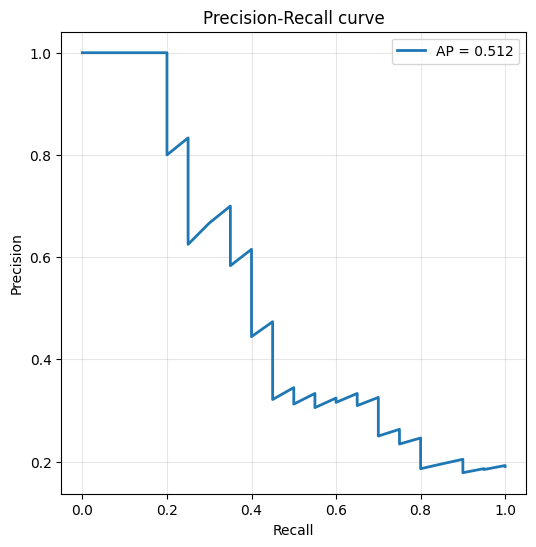

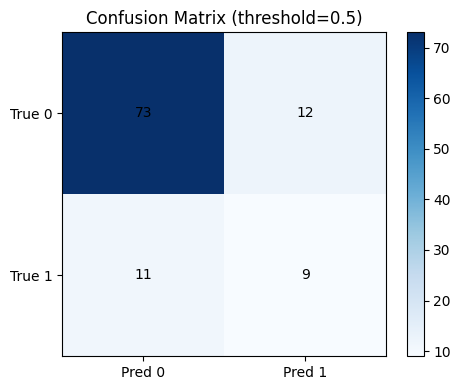

MAP: 100%|██████████| 2000/2000 [00:08<00:00, 223.96it/s, logpost=-60.9752, loglik=-60.1107, logprior=-0.8645, patience=0]


{'mean_auc': 0.5879087833963995, 'std_auc': 0.13696733297895725, 'min_auc': np.float64(0.4210526315789474), 'max_auc': np.float64(0.7625000000000001), 'n_folds': 5}


In [9]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S1_c.pkl")

### Model $\mathbb{S}^2$

#### With weights

Multi_start (1)


MAP: 100%|██████████| 20000/20000 [01:30<00:00, 220.43it/s, logpost=-27.1036, loglik=-26.1813, logprior=-0.9223, patience=0]



Best log-posterior: -27.1036


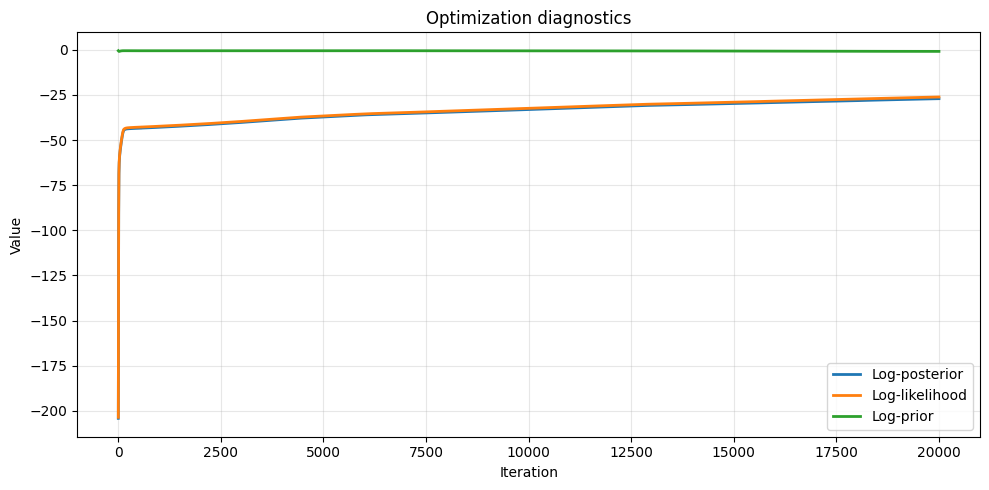

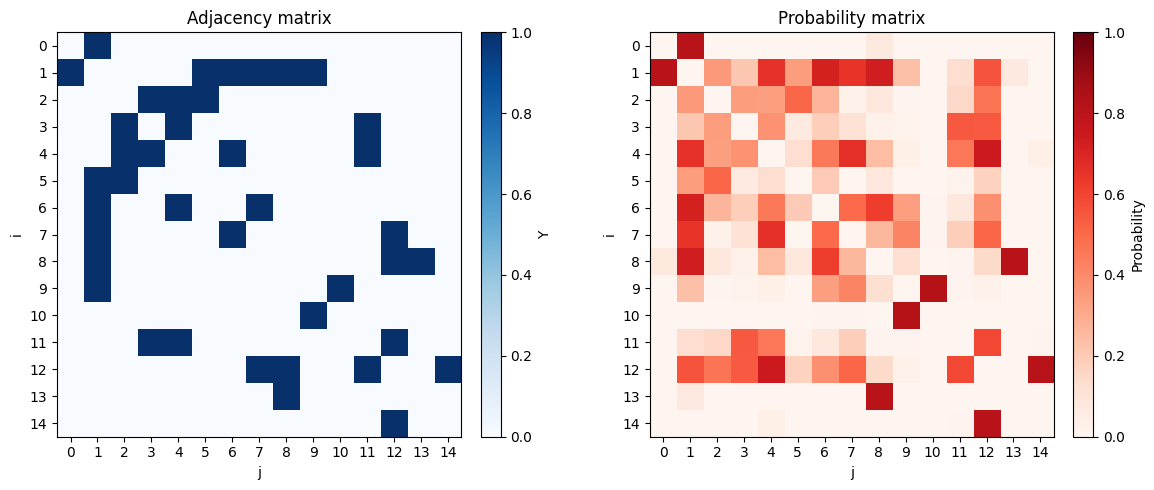

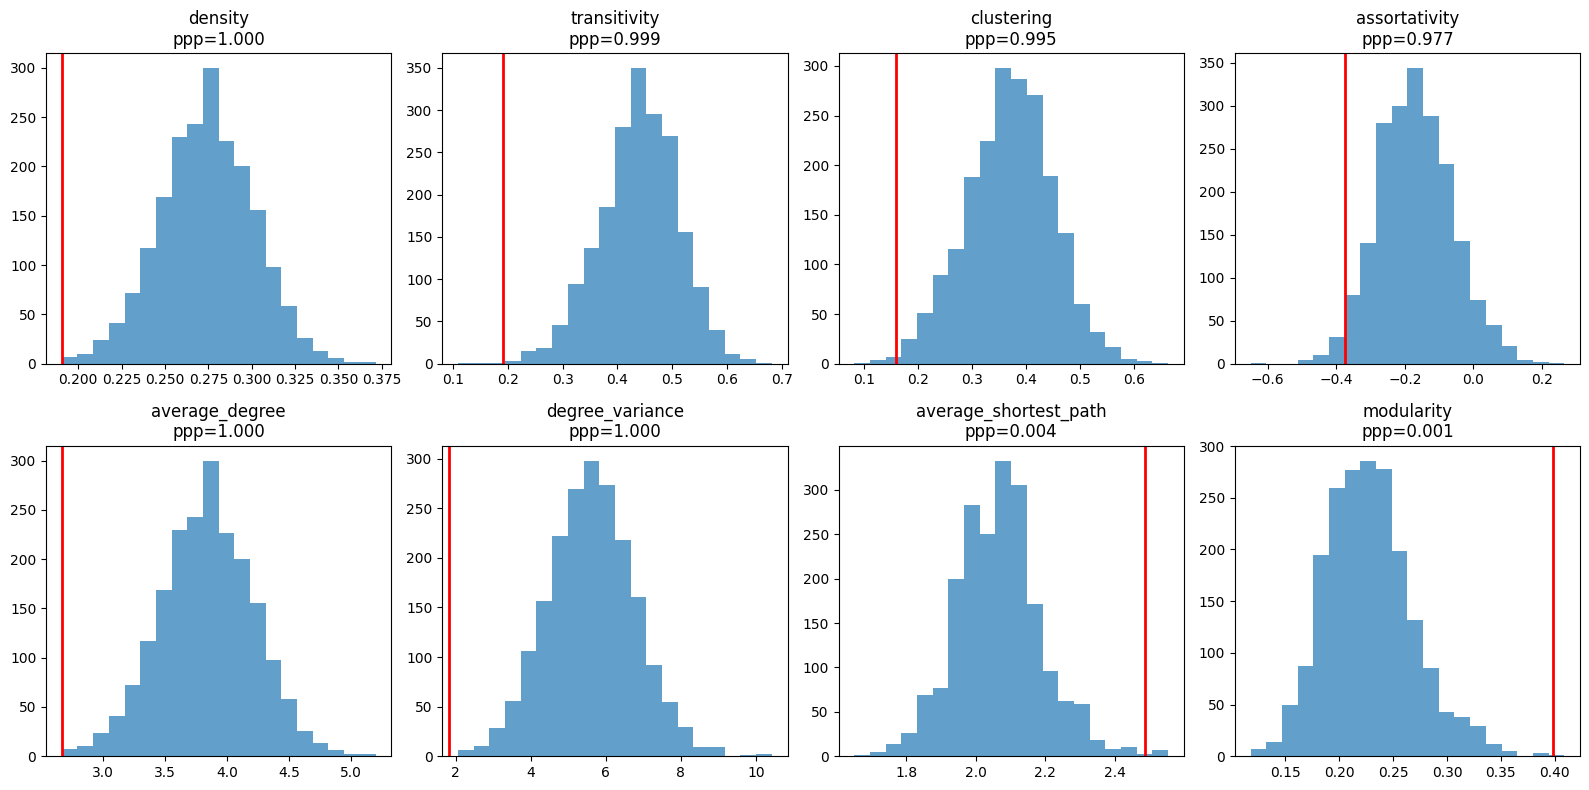

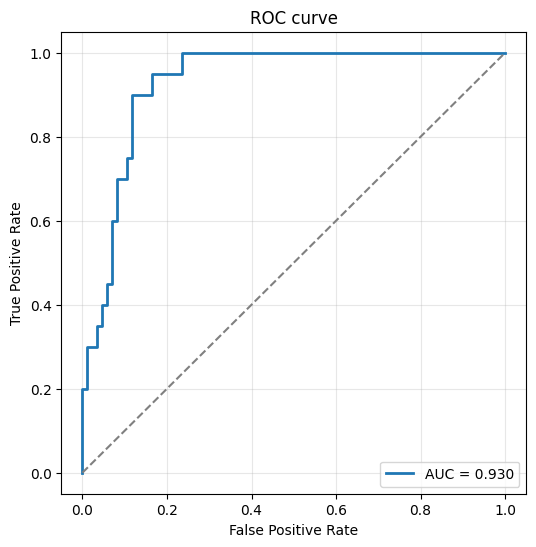

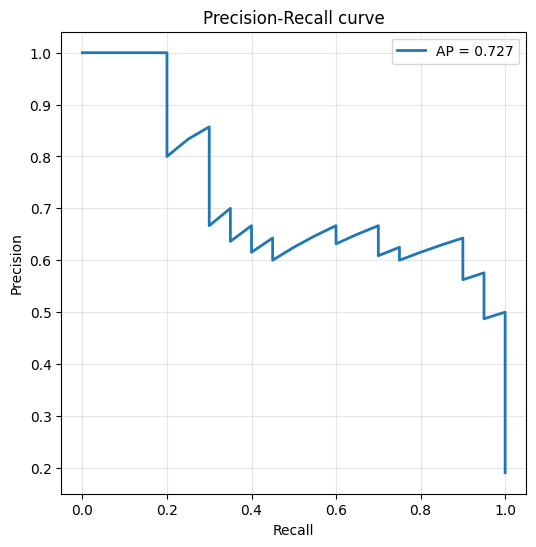

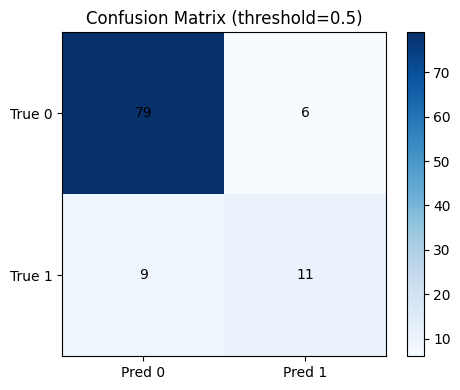

MAP: 100%|██████████| 2000/2000 [00:08<00:00, 223.79it/s, logpost=-14.3584, loglik=-13.2009, logprior=-1.1576, patience=0]


{'mean_auc': 0.7529325765393876, 'std_auc': 0.13877022901418076, 'min_auc': np.float64(0.575), 'max_auc': np.float64(0.9444444444444444), 'n_folds': 5}


In [10]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S2_p.pkl")

#### Without weights

Multi_start (1)


MAP: 100%|██████████| 20000/20000 [01:29<00:00, 222.58it/s, logpost=-24.6817, loglik=-21.1320, logprior=-3.5497, patience=0]



Best log-posterior: -24.6817


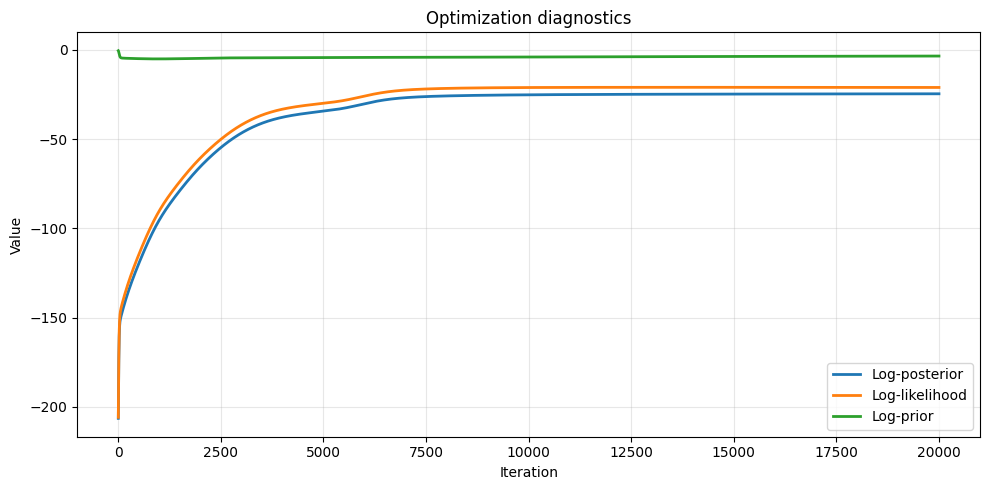

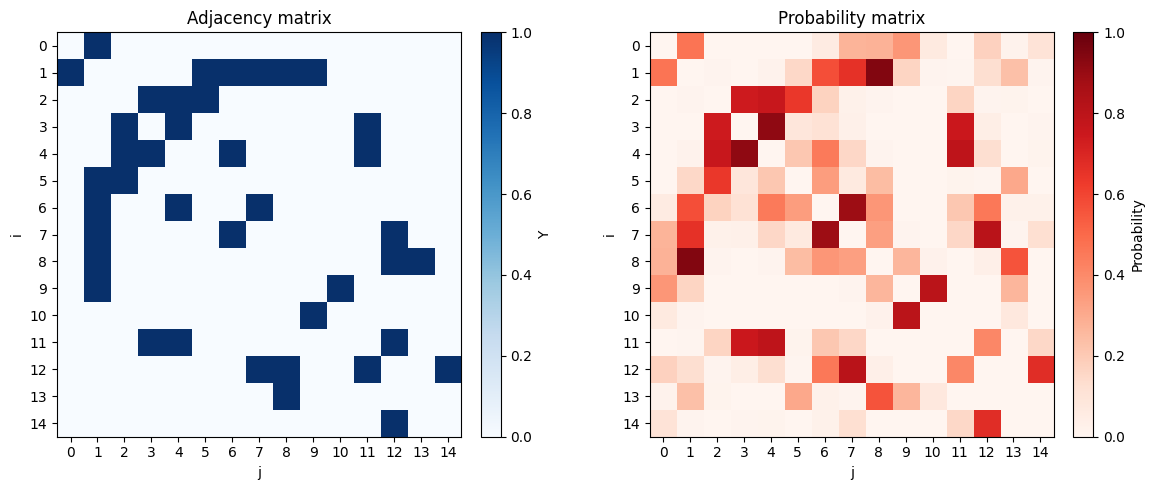

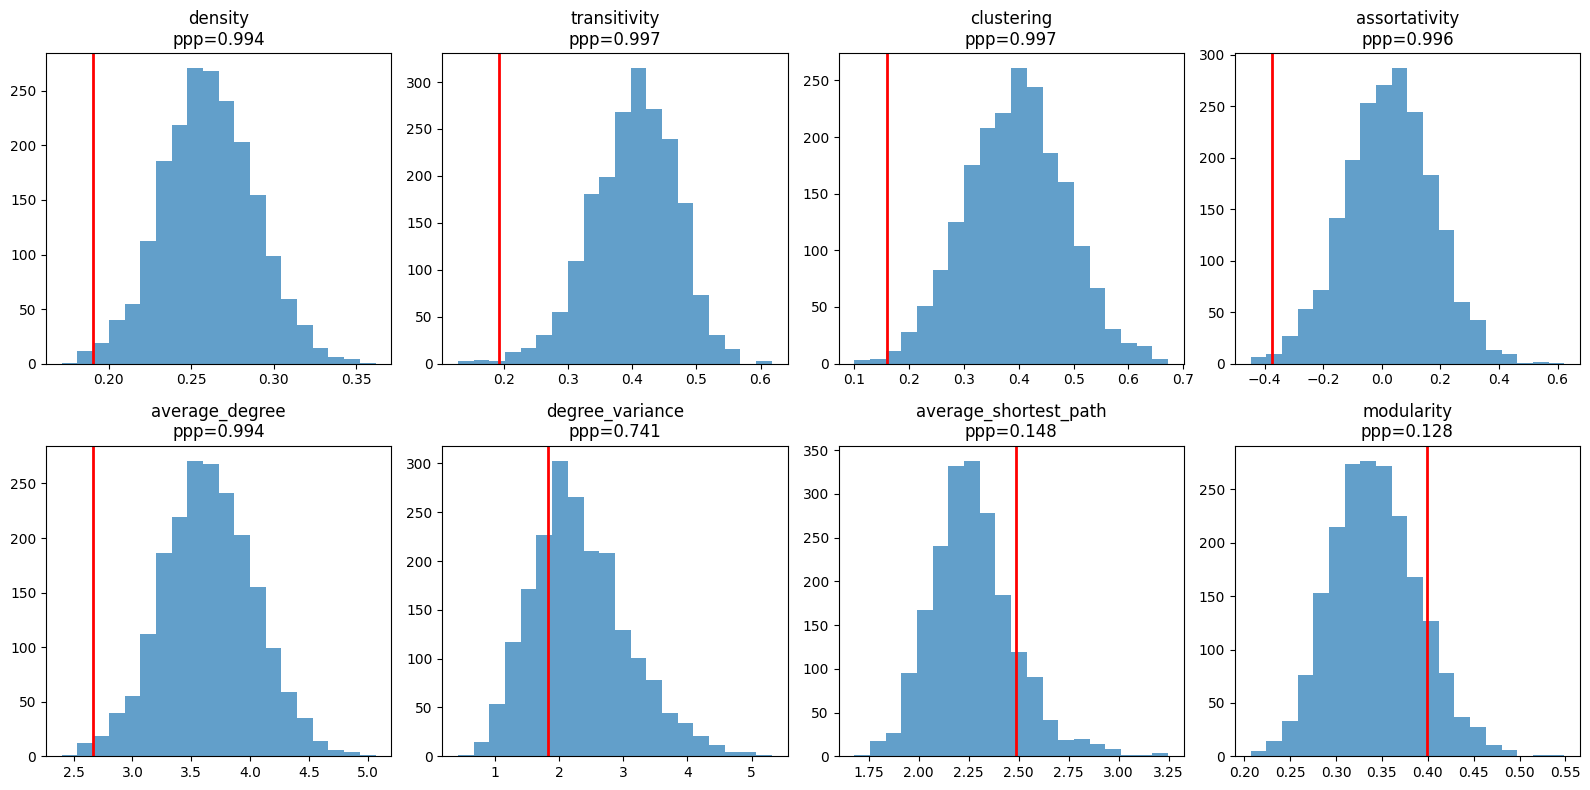

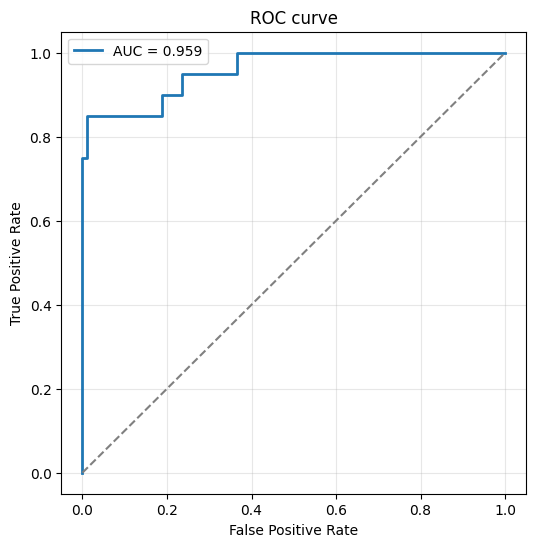

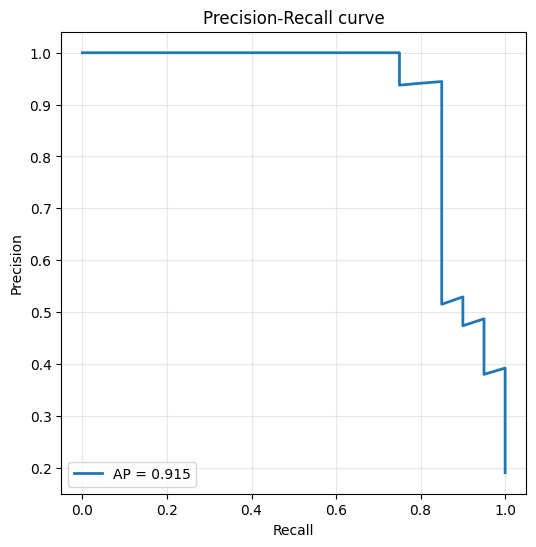

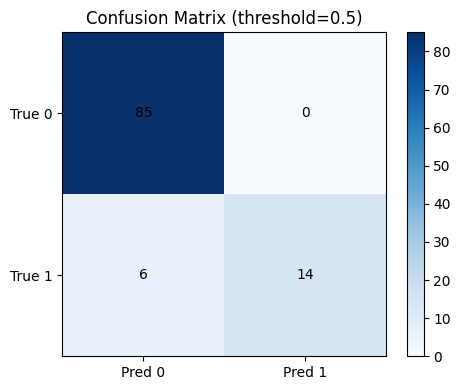

MAP: 100%|██████████| 2000/2000 [00:09<00:00, 209.69it/s, logpost=-11.5656, loglik=-8.8165, logprior=-2.7491, patience=0]


{'mean_auc': 0.8893102855177158, 'std_auc': 0.07027938620928526, 'min_auc': np.float64(0.8), 'max_auc': np.float64(0.9852941176470588), 'n_folds': 5}


In [11]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S2_c.pkl")

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

#### With weights

Multi_start (1)


MAP:   1%|          | 150/20000 [00:01<03:25, 96.63it/s, logpost=-67.6058, loglik=-67.0552, logprior=-0.5506, patience=100] 


[STOP] Early stopping at iter 149 (no improvement in 101 steps)

Best log-posterior: -67.6058


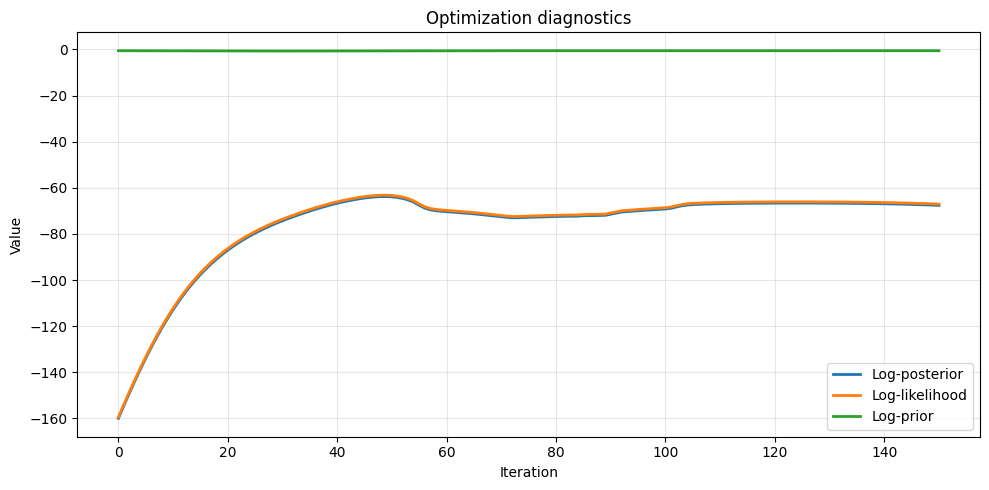

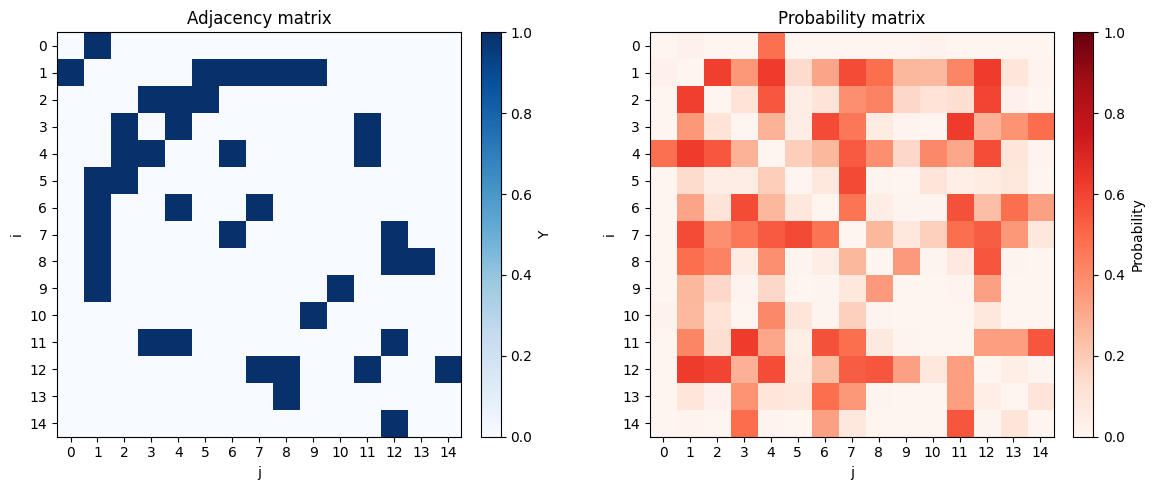

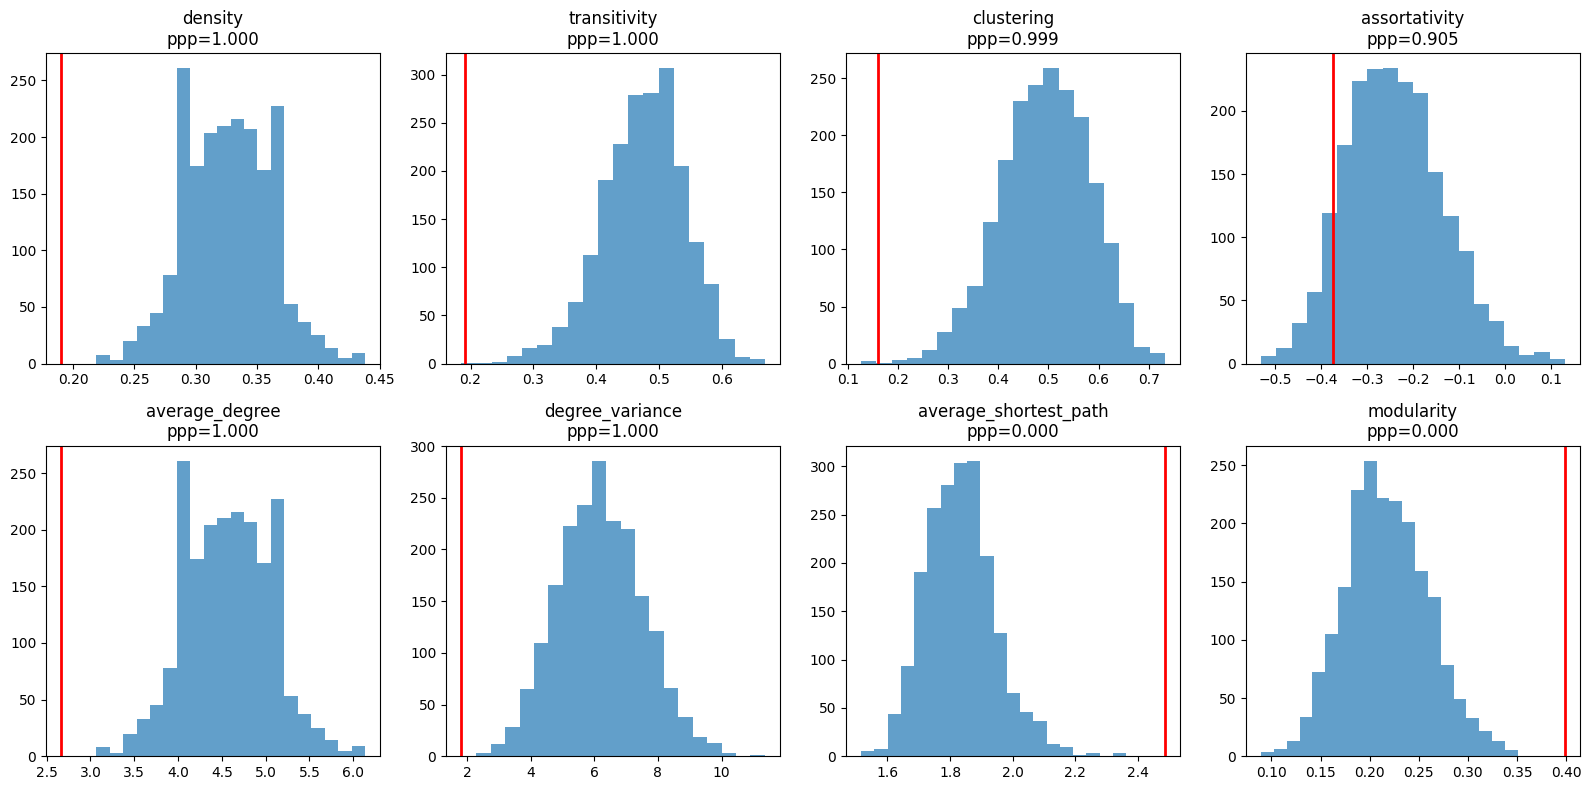

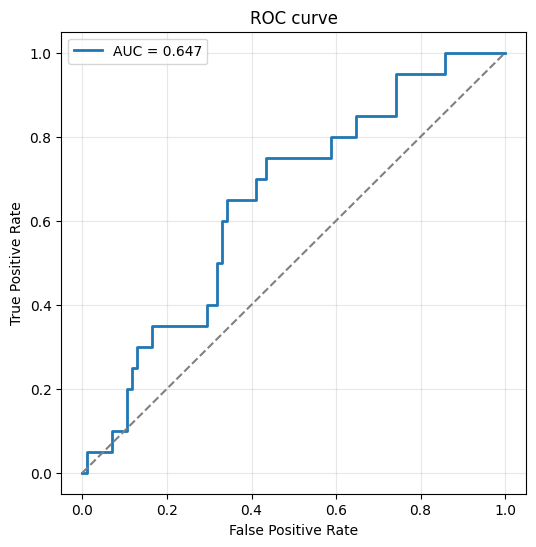

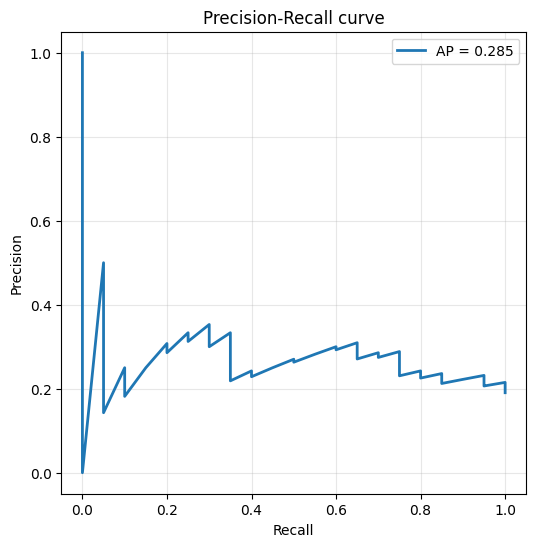

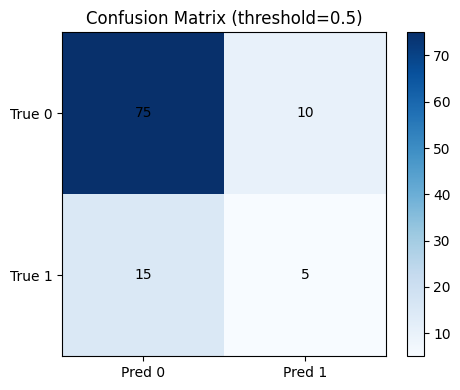

MAP:   2%|▎         | 50/2000 [00:00<00:34, 57.10it/s, logpost=-49.2664, loglik=-48.7168, logprior=-0.5496, patience=49]


{'mean_auc': 0.45500171998624006, 'std_auc': 0.19390022620497532, 'min_auc': np.float64(0.17647058823529413), 'max_auc': np.float64(0.6499999999999999), 'n_folds': 5}


In [12]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H1_p.pkl")

#### Without weights

Multi_start (1)


MAP:   1%|          | 150/20000 [00:01<02:51, 116.03it/s, logpost=-113.6586, loglik=-112.5874, logprior=-1.0712, patience=100]


[STOP] Early stopping at iter 149 (no improvement in 101 steps)

Best log-posterior: -113.6586


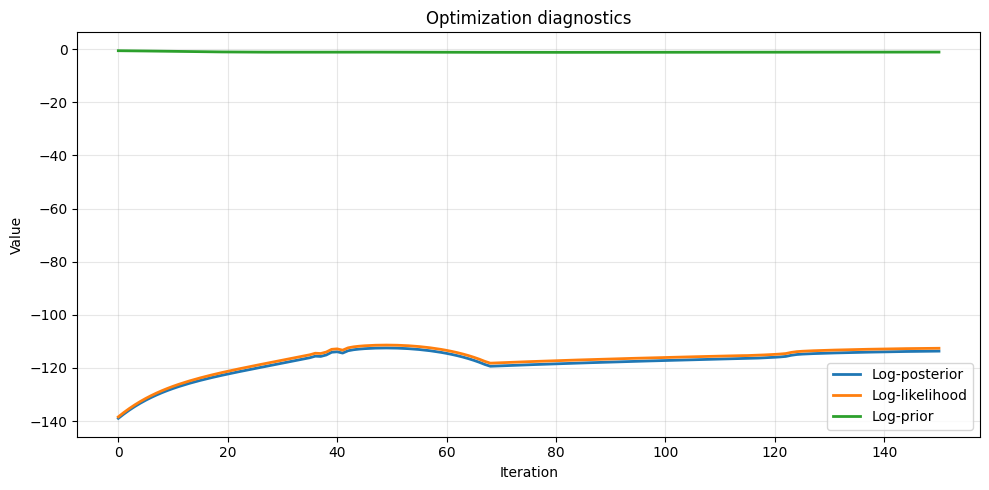

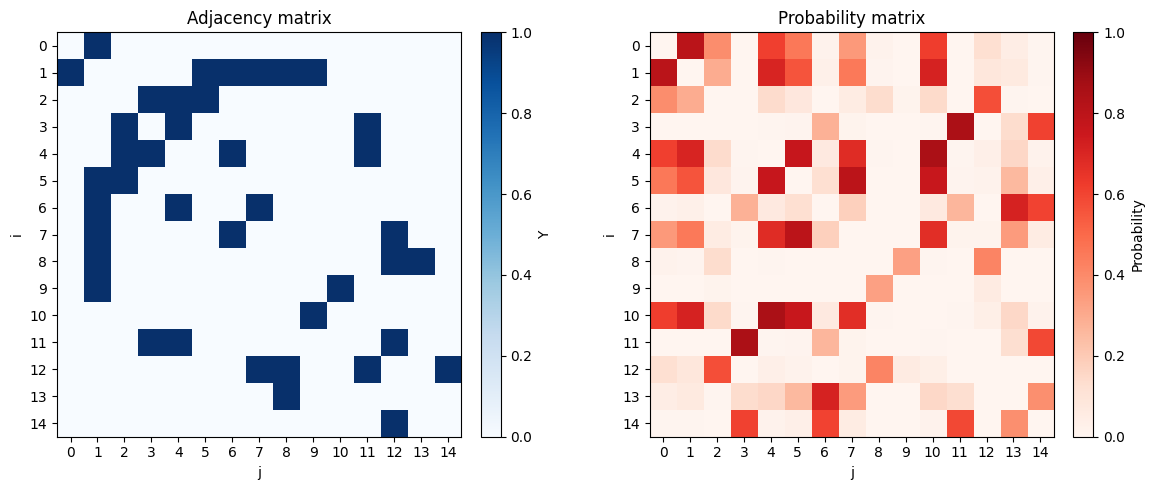

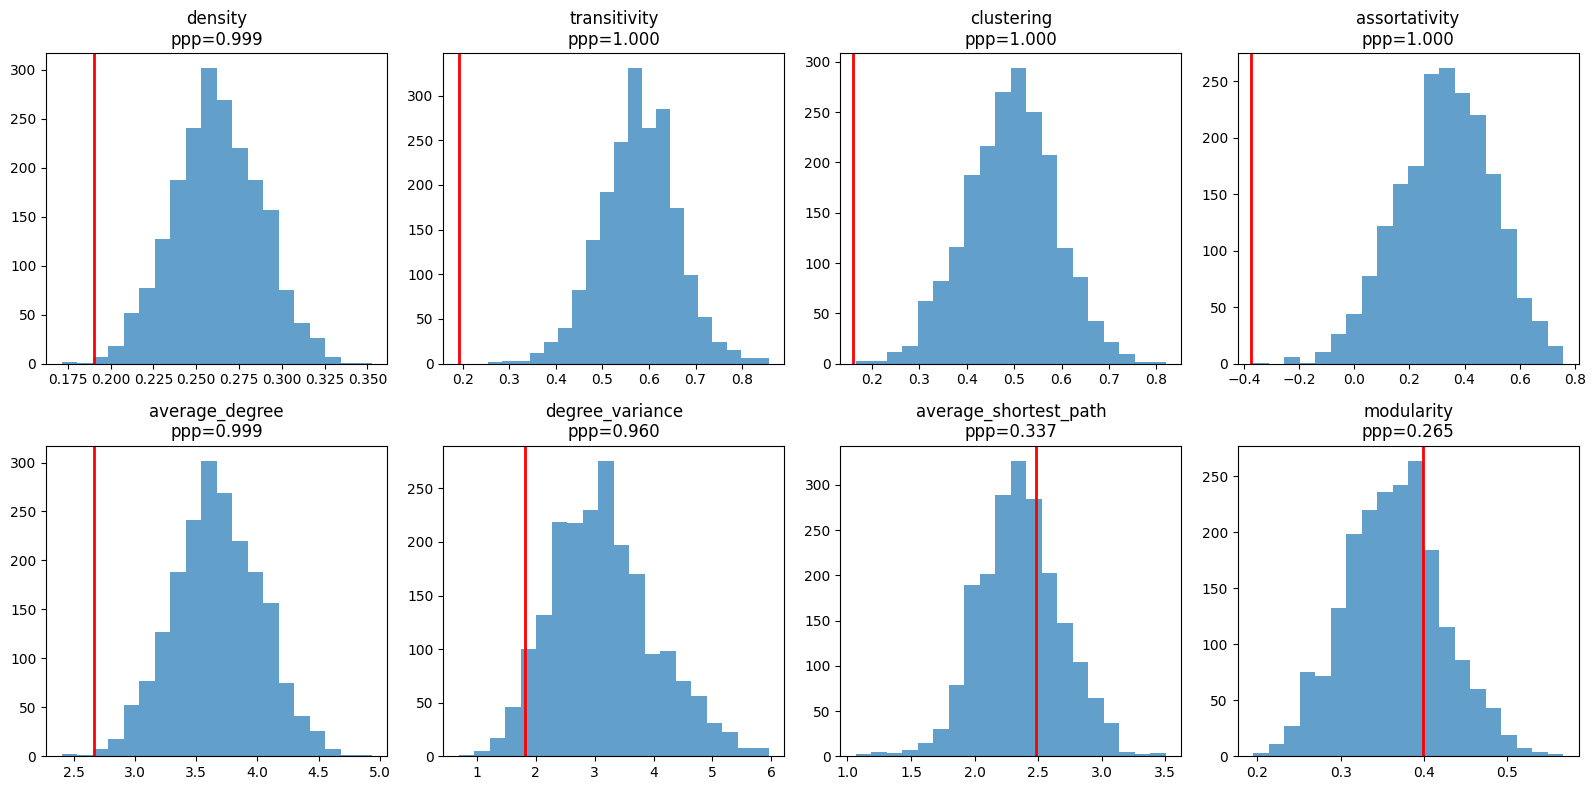

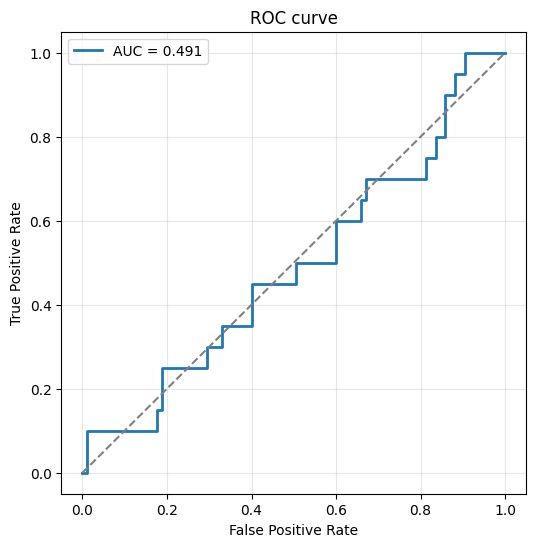

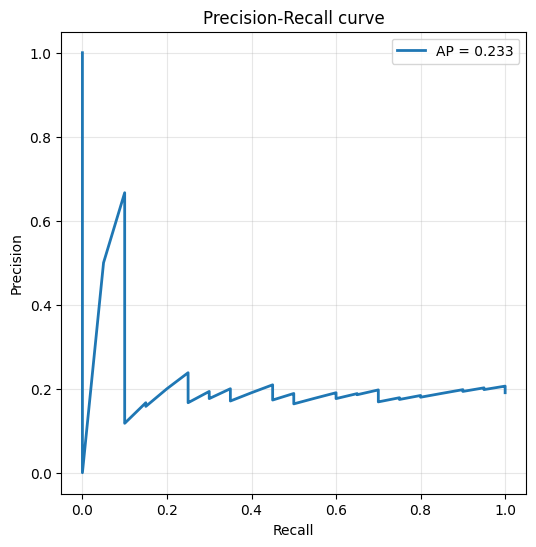

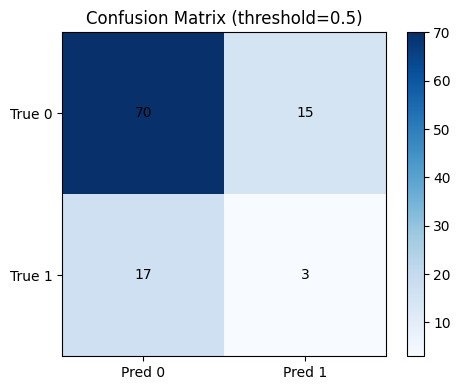

MAP:   2%|▎         | 50/2000 [00:00<00:27, 70.33it/s, logpost=-88.6823, loglik=-87.7689, logprior=-0.9134, patience=49]


{'mean_auc': 0.522888143561518, 'std_auc': 0.10263422752641922, 'min_auc': np.float64(0.3235294117647059), 'max_auc': np.float64(0.6052631578947368), 'n_folds': 5}


In [13]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H1_c.pkl")

### Model $\mathbb{H}^2$

#### With weights

Multi_start (1)


MAP:  21%|██▏       | 4296/20000 [00:20<01:14, 210.28it/s, logpost=-44.7925, loglik=-44.2227, logprior=-0.5698, patience=100]


[STOP] Early stopping at iter 4295 (no improvement in 101 steps)

Best log-posterior: -44.7925


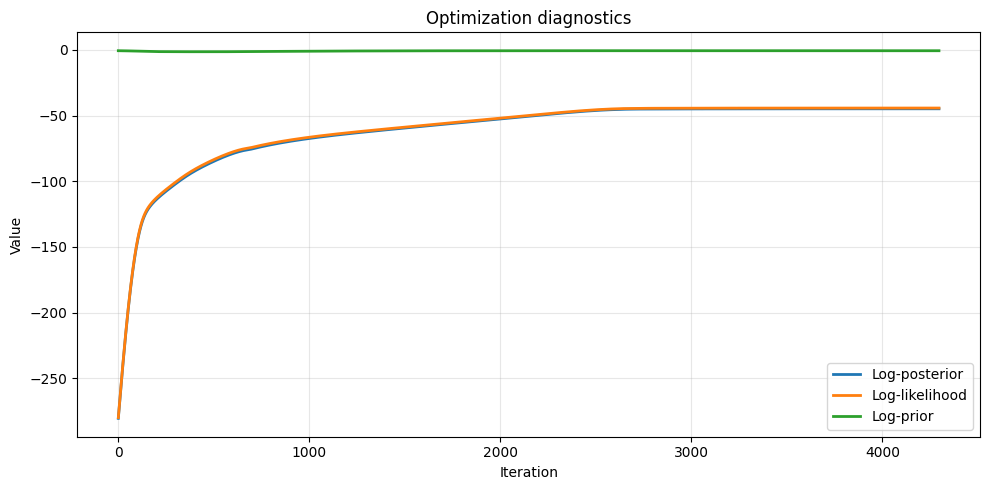

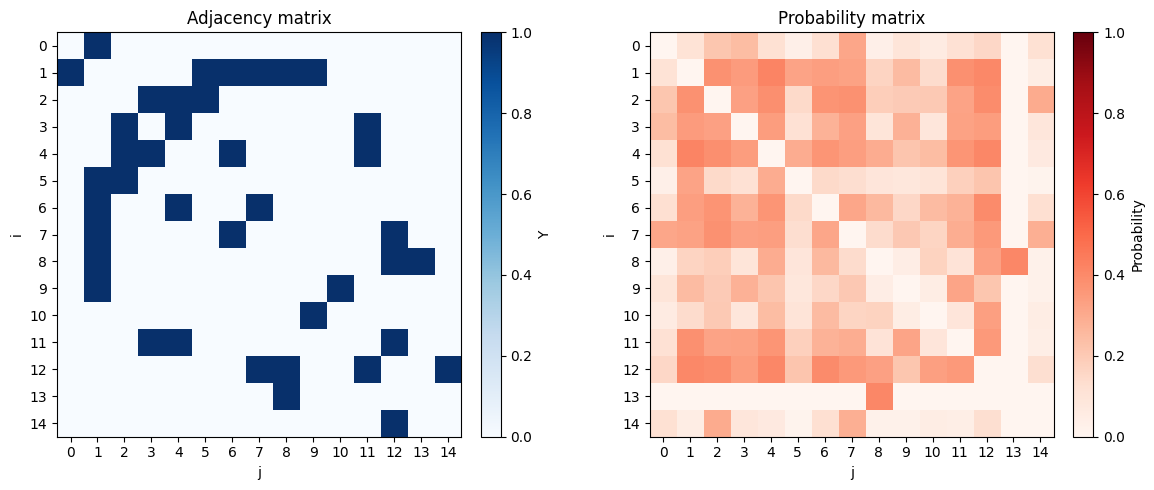

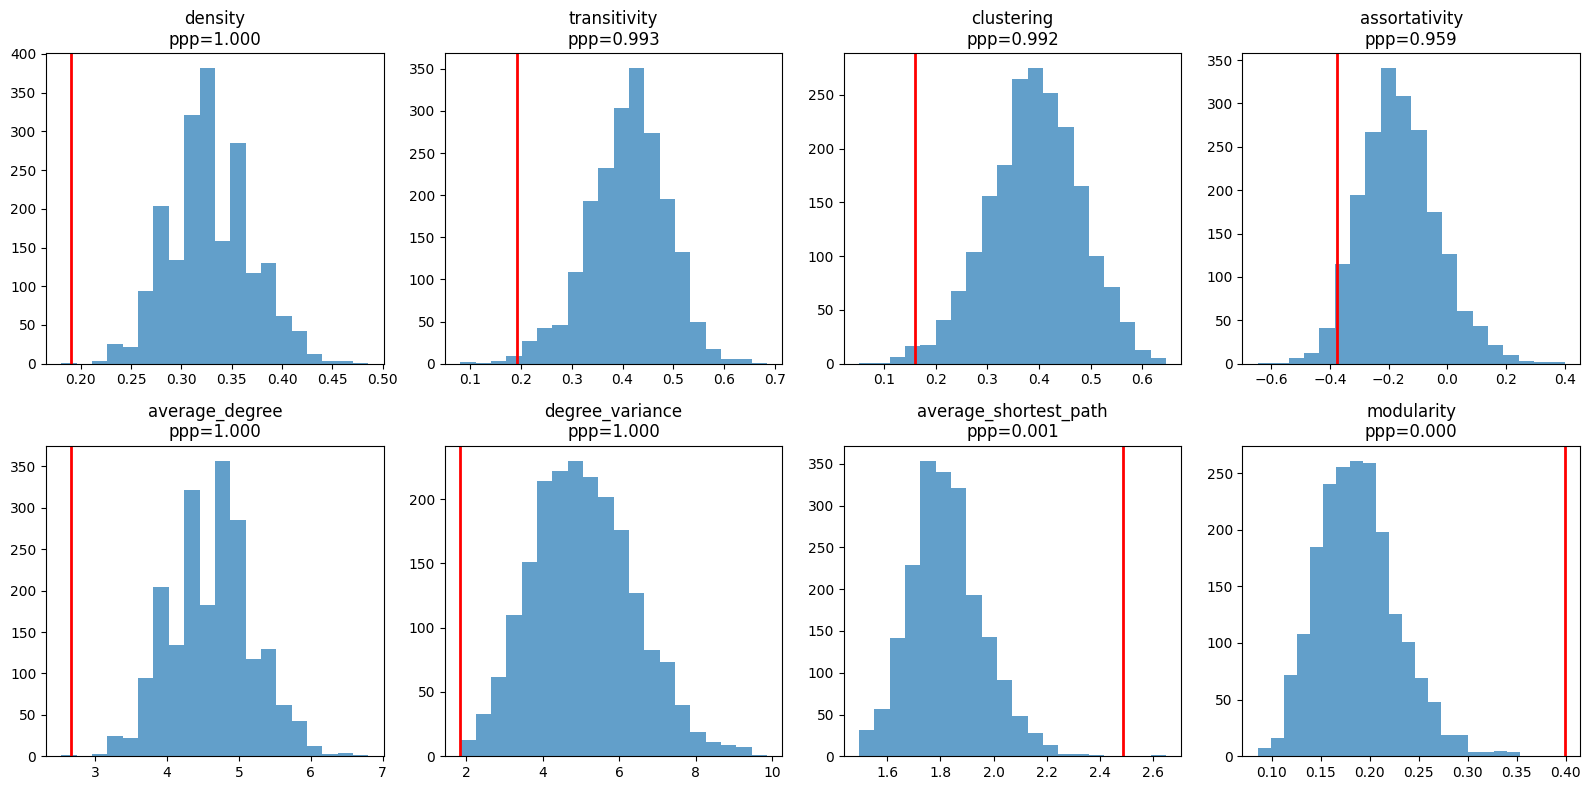

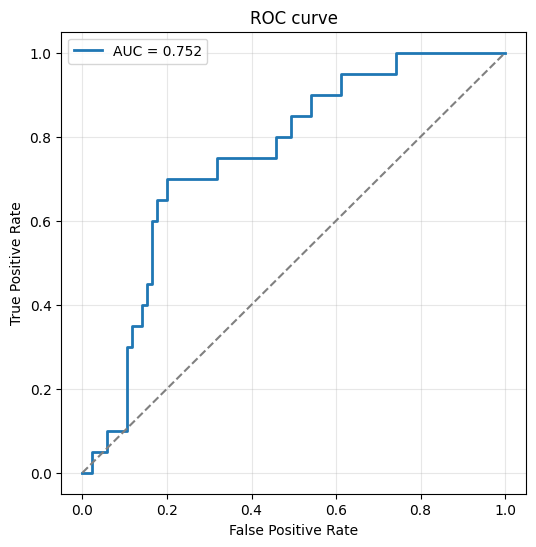

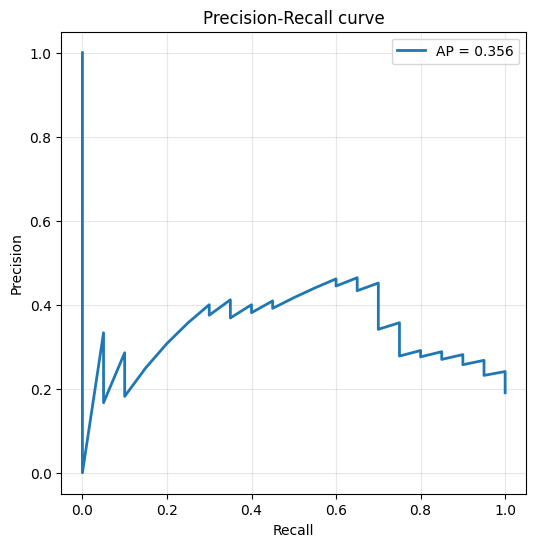

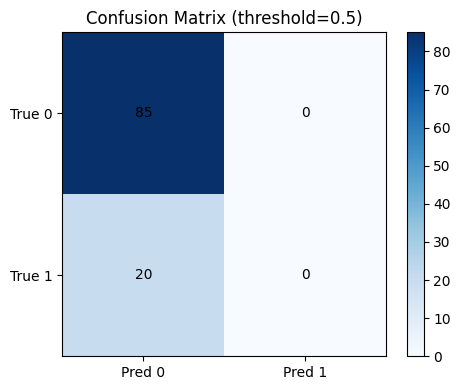

MAP: 100%|██████████| 2000/2000 [00:09<00:00, 205.83it/s, logpost=-31.2050, loglik=-30.6087, logprior=-0.5963, patience=0]


{'mean_auc': 0.42502751977984177, 'std_auc': 0.06017485867722486, 'min_auc': np.float64(0.3235294117647059), 'max_auc': np.float64(0.5111111111111111), 'n_folds': 5}


In [18]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=0.1*lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=0.1*lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H2_p.pkl")

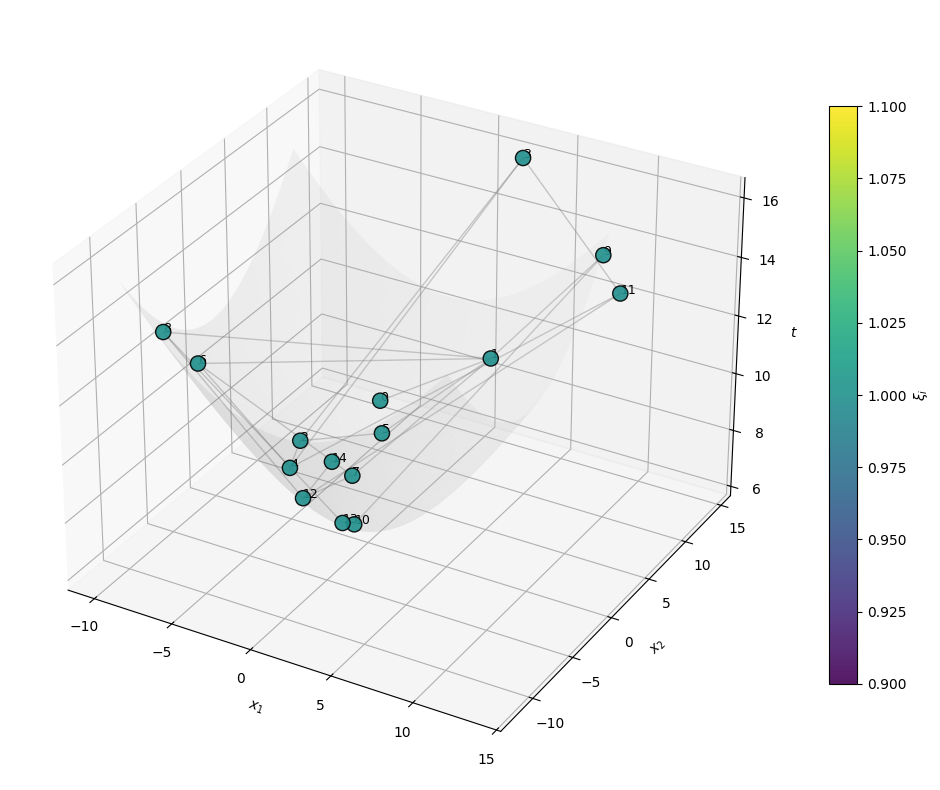

In [29]:


Z = np.array(model.inferred["MAP"]["final_params"]["Z"])
xi = np.array(model.inferred["MAP"]["final_params"]["xi"])

R = geometry.R

# malla del hiperboloide
x = np.linspace(-diam/2, diam/2, 200)
y = np.linspace(-diam/2, diam/2, 200)

X, Y = np.meshgrid(x, y)
T = np.sqrt(R**2 + X**2 + Y**2)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# hiperboloide
ax.plot_surface(
    X,
    Y,
    T,
    alpha=0.1,
    linewidth=0,
    color="lightgray"
)

# embedding coloreado por xi
sc = ax.scatter(
    Z[:, 0],
    Z[:, 1],
    Z[:, 2],
    c=xi,
    cmap="viridis",
    s=120,
    edgecolors="black",
    alpha=0.9
)

# etiquetas
for i, (x_i, y_i, t_i) in enumerate(Z):
    ax.text(
        x_i,
        y_i,
        t_i,
        str(i),
        fontsize=9
    )

Y = np.array(model.Y)

for i in range(len(Z)):
    for j in range(i+1, len(Z)):
        if Y[i,j] == 1:
            ax.plot(
                [Z[i,0], Z[j,0]],
                [Z[i,1], Z[j,1]],
                [Z[i,2], Z[j,2]],
                alpha=0.4,
                linewidth=1,
                color="gray"
            )

# colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
cbar.set_label(r"$\xi_i$")

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_zlabel(r"$t$")

plt.tight_layout()
plt.show()

#### Without weights

Multi_start (1)


MAP:  11%|█         | 2195/20000 [00:10<01:22, 215.92it/s, logpost=-164.7164, loglik=-160.3325, logprior=-4.3839, patience=100]


[STOP] Early stopping at iter 2194 (no improvement in 101 steps)

Best log-posterior: -164.7164


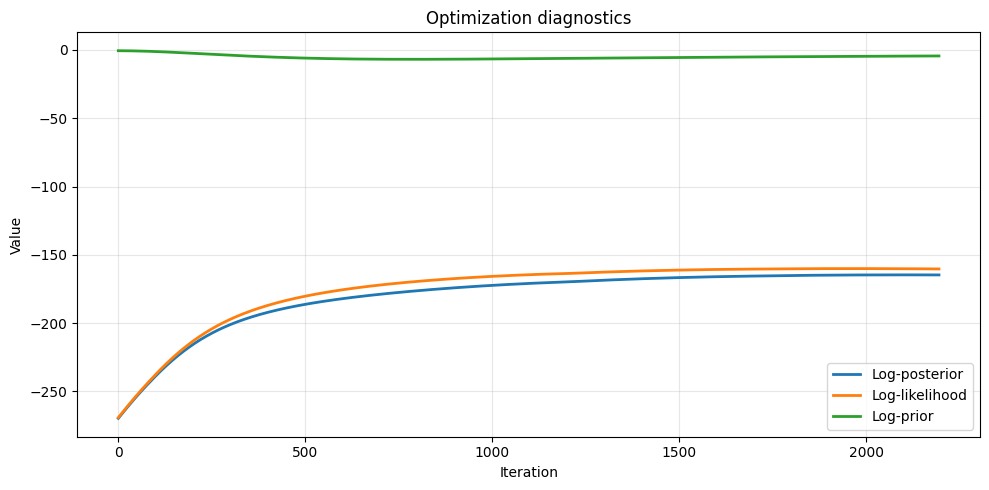

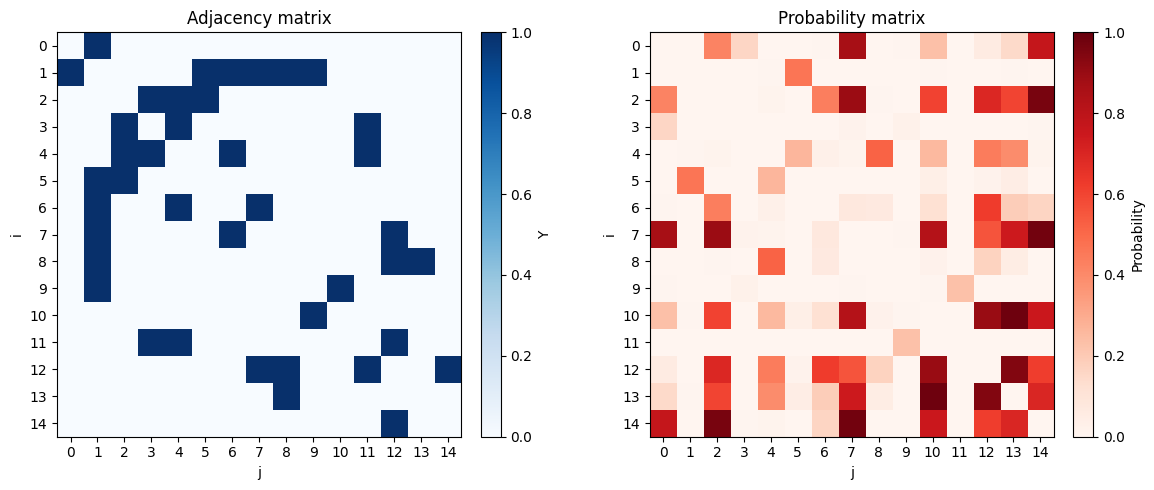

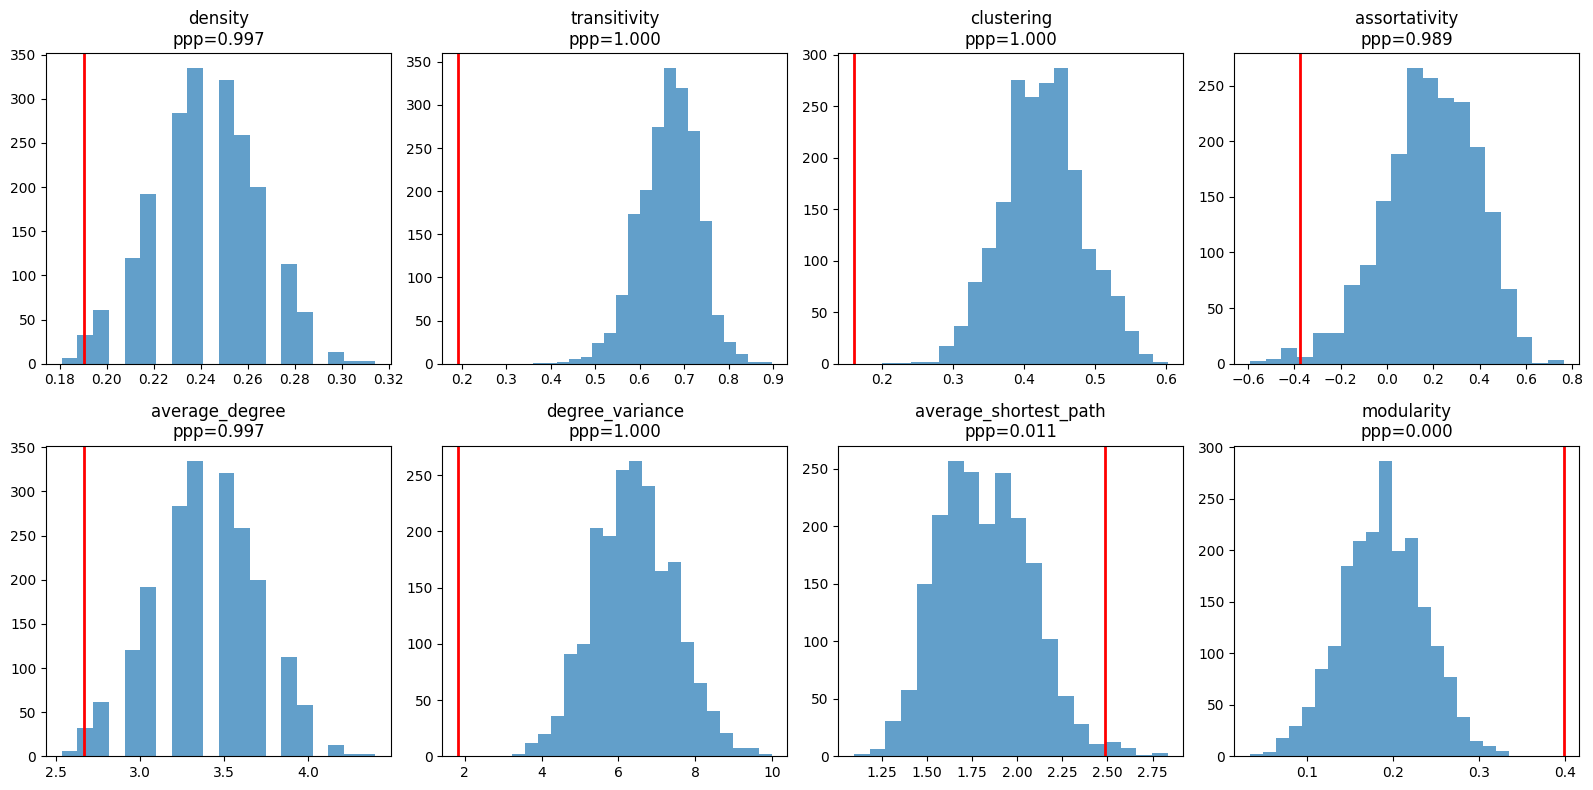

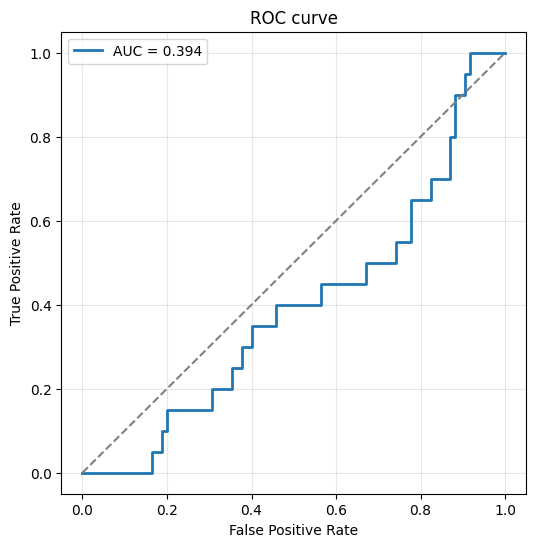

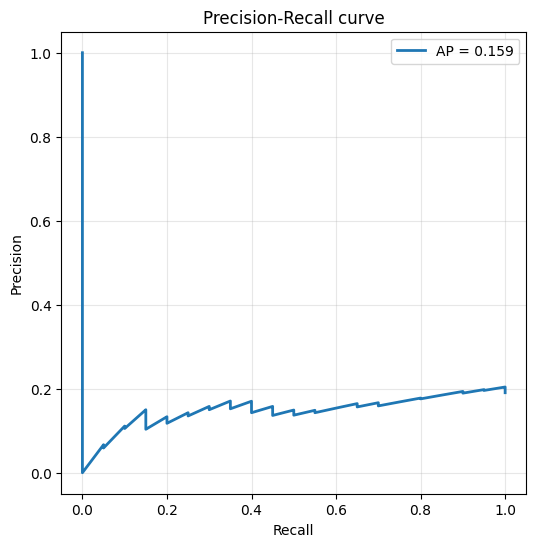

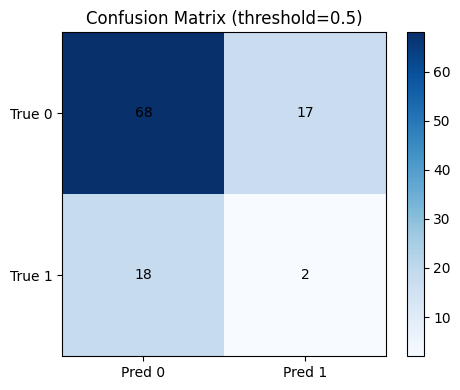

MAP: 100%|██████████| 2000/2000 [00:09<00:00, 206.55it/s, logpost=-118.4546, loglik=-115.5191, logprior=-2.9355, patience=0]


{'mean_auc': 0.33989192753124636, 'std_auc': 0.18313799752135546, 'min_auc': np.float64(0.03703703703703705), 'max_auc': np.float64(0.5875), 'n_folds': 5}


In [27]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=0.1*lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=0.1*lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H2_c.pkl")

## Results

### Visualization of latent spaces 

### Visualization of probability matrices

### Model statistics

### Internal validation

### External validation